# TP Final: Clasificación de Objetos Astronómicos (SDSS DR17)

### Aprendizaje de Máquina I · CEIA · FIUBA

**Grupo 9**

- Marcos Levi Riveros Koloszwa
- Franco Marcelo Morero
- Tadeo Riveros

## Resumen

El **Sloan Digital Sky Survey (SDSS)** es uno de los relevamientos del cielo más extensos disponibles. A partir de sus observaciones, nuestro objetivo es **clasificar automáticamente** cada objeto detectado en una de tres categorías:

| Clase | Qué es |
|---|---|
| **STAR** | Una estrella de nuestra galaxia |
| **GALAXY** | Otra galaxia |
| **QSO** (cuásar) | El núcleo brillante de una galaxia con un agujero negro supermasivo |

**El problema:** el SDSS observa cientos de millones de objetos. Clasificarlos manualmente no es viable, así que un modelo automático y confiable es indispensable para aprovechar los datos a gran escala.

Realizamos un análisis exploratorio completo (EDA) y entrenamos modelos basados en **árboles de decisión** (XGBoost y CatBoost), optimizados con **Optuna**. Partimos de un **baseline heurístico** que nos sirve como referencia para medir cuánto aporta cada decisión posterior.

## Datos

- **Fuente:** Kaggle, *Stellar Classification Dataset SDSS17* (fedesoriano). https://www.kaggle.com/fedesoriano/stellar-classification-dataset-sdss17
- **Origen primario:** Sloan Digital Sky Survey, Data Release 17. https://www.sdss.org/
- **Observaciones:** 100.000. **Target:** `class` ∈ {GALAXY, STAR, QSO}. **Features:** 17 columnas.

### Diccionario de variables

| Variable | Descripción |
|---|---|
| `obj_ID` | Identificador único del objeto en el catálogo CAS |
| `alpha` | Ascensión recta (J2000) |
| `delta` | Declinación (J2000) |
| `u`, `g`, `r`, `i`, `z` | Magnitudes en los filtros fotométricos SDSS (del UV al IR cercano) |
| `run_ID`, `rerun_ID`, `cam_col`, `field_ID` | Identificadores técnicos de adquisición |
| `spec_obj_ID` | ID del objeto espectroscópico |
| `class` | Clase del objeto (**target**) |
| `redshift` | Corrimiento al rojo |
| `plate`, `MJD`, `fiber_ID` | Identificadores de la observación espectroscópica |

## Índice

1. **Contexto del dominio** (filtros y redshift)
2. **Análisis Exploratorio de Datos (EDA)**
3. **Preparación de datos** y *feature engineering*
4. **Heurística baseline** 
5. **¿Por qué árboles?** Justificación de la elección del modelo
6. **Modelado:** XGBoost y CatBoost con Optuna
7. **Evaluación e interpretabilidad**
8. **Conclusiones**
9. **Apéndice de Modelos Extras**
10. **Referencias y bibliografía**

# 1. Contexto del dominio

Detrás de las columnas del dataset hay dos conceptos físicos clave: los **filtros fotométricos** (`u, g, r, i, z`) y el **redshift** (`redshift`). Los repasamos brevemente antes de pasar al análisis.

## 1.1 La luz y los filtros del SDSS

La luz visible es apenas una porción del **espectro electromagnético**, que va desde las ondas de radio hasta los rayos gamma. Lo que percibe el ojo humano ocupa una franja estrecha, entre los ~400 y ~750 nanómetros.

![Espectro electromagnético](images/sky-bas-col-what-im2.gif)

La cámara del SDSS observa el cielo a través de **cinco filtros de color**. Cada uno deja pasar solo cierto rango de longitudes de onda y mide cuánta luz llega en esa franja:

| Filtro | Qué capta |
|---|---|
| `u` | Ultravioleta cercano |
| `g` | Azul-verde (visible) |
| `r` | Amarillo-rojo (visible) |
| `i` | Infrarrojo cercano |
| `z` | Infrarrojo cercano (más lejano) |

En conjunto, la cámara es sensible desde los ~300 nm (UV) hasta los ~1050 nm (IR), bastante más allá de lo que alcanza la vista humana.

![Ventanas de los filtros u,g,r,i,z](images/filters.jpg)

Cada columna `u, g, r, i, z` representa el brillo del objeto medido a través de uno de estos filtros. Las *diferencias* entre filtros (los **índices de color**, por ejemplo `u-g`) resumen la "forma" del espectro y son muy informativas para separar tipos de objetos.

<sub>Imágenes: SDSS Voyages. https://voyages.sdss.org/preflight/light/filters/</sub>

## 1.2 El *redshift* (corrimiento al rojo)

Los átomos emiten luz en longitudes de onda muy precisas, las **líneas espectrales**. Cuando un objeto se aleja de nosotros, esas líneas aparecen **corridas hacia el rojo**, hacia longitudes de onda más largas. Cuanto más lejos está o más rápido se aleja, mayor es ese corrimiento.

![Corrimiento de las líneas espectrales](images/spectra-comparison.png)

![Redshift y blueshift](images/redshiftblueshift.png)

El **redshift** ($z$) se define como:

$$ z = \frac{\lambda_{\text{observada}} - \lambda_{\text{emitida}}}{\lambda_{\text{emitida}}} $$

Detrás del corrimiento hay dos efectos:

- **Efecto Doppler:** igual que el sonido de un auto que pasa, si la fuente se aleja la onda se estira.
- **Redshift cosmológico:** el propio espacio se expande y estira la luz durante su viaje. Es el efecto dominante en los objetos más lejanos.

### Por qué el redshift separa las clases

| Clase | Redshift típico | Por qué |
|---|---|---|
| STAR | $z \approx 0$ | Está en nuestra galaxia, prácticamente quieta respecto a nosotros |
| GALAXY | $z$ intermedio (~0,05 a 1) | Galaxias a distancias cosmológicas |
| QSO | $z$ alto (1 a >6) | Objetos muy lejanos y antiguos |

Esta es la **hipótesis central** que verificamos en el EDA y aprovechamos en el modelado: esperamos que el `redshift` sea, por amplio margen, el predictor más fuerte. Para ponerla a prueba, **entrenamos modelos con y sin redshift** y comparamos su desempeño.

<sub>Imágenes: SDSS Voyages. https://voyages.sdss.org/preflight/light/redshift/</sub>

# 2. Análisis Exploratorio de Datos (EDA)

Antes de modelar dedicamos tiempo a entender los datos a fondo: qué representa cada variable, qué tan limpios están, cómo se distribuyen y cómo se relacionan entre sí. Cada decisión de preprocesamiento y de modelado que tomamos más adelante se apoya en lo que encontramos en esta sección.

## Exploración y comprensión de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings("ignore")

sns.set_theme()
pd.set_option("display.max_columns", None)

# Semilla global para reproducibilidad
SEED = 42 # "What is the Answer to the Ultimate Question of Life, the Universe, and Everything?"
np.random.seed(SEED)

### Cargar el dataset

In [2]:
df = pd.read_csv("star_classification.csv")
df.shape

(100000, 18)

### Describir las características principales

In [3]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [4]:
df.tail()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470
99999,1.237661e+18,196.896053,49.464643,22.62171,21.79745,20.60115,20.00959,19.28075,3650,301,4,60,8.343152e+18,GALAXY,0.542944,7410,57104,851


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237665e+18,8.438560e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


**Observaciones iniciales**

El dataset tiene 100.000 filas y 18 columnas. Al revisar los datos podemos ver varias cosas:

- `rerun_ID` toma siempre el valor 301: es una columna constante y no aporta información.
- Los mínimos de `u`, `g` y `z` son `-9999`. No es un valor físico, hay que analizar en busca de datos faltantes.
- `redshift` va desde un mínimo levemente negativo (cercano a 0) hasta un máximo de alrededor de 7, un rango amplio que tendremos en cuenta al escalar.
- `obj_ID` y `spec_obj_ID` son numéricos, pero funcionan como identificadores: son categóricos por naturaleza y no deberían entrar como variables continuas.

# Análisis de nulos y duplicados

In [7]:
df.isna().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

In [8]:
df.duplicated().sum()

0

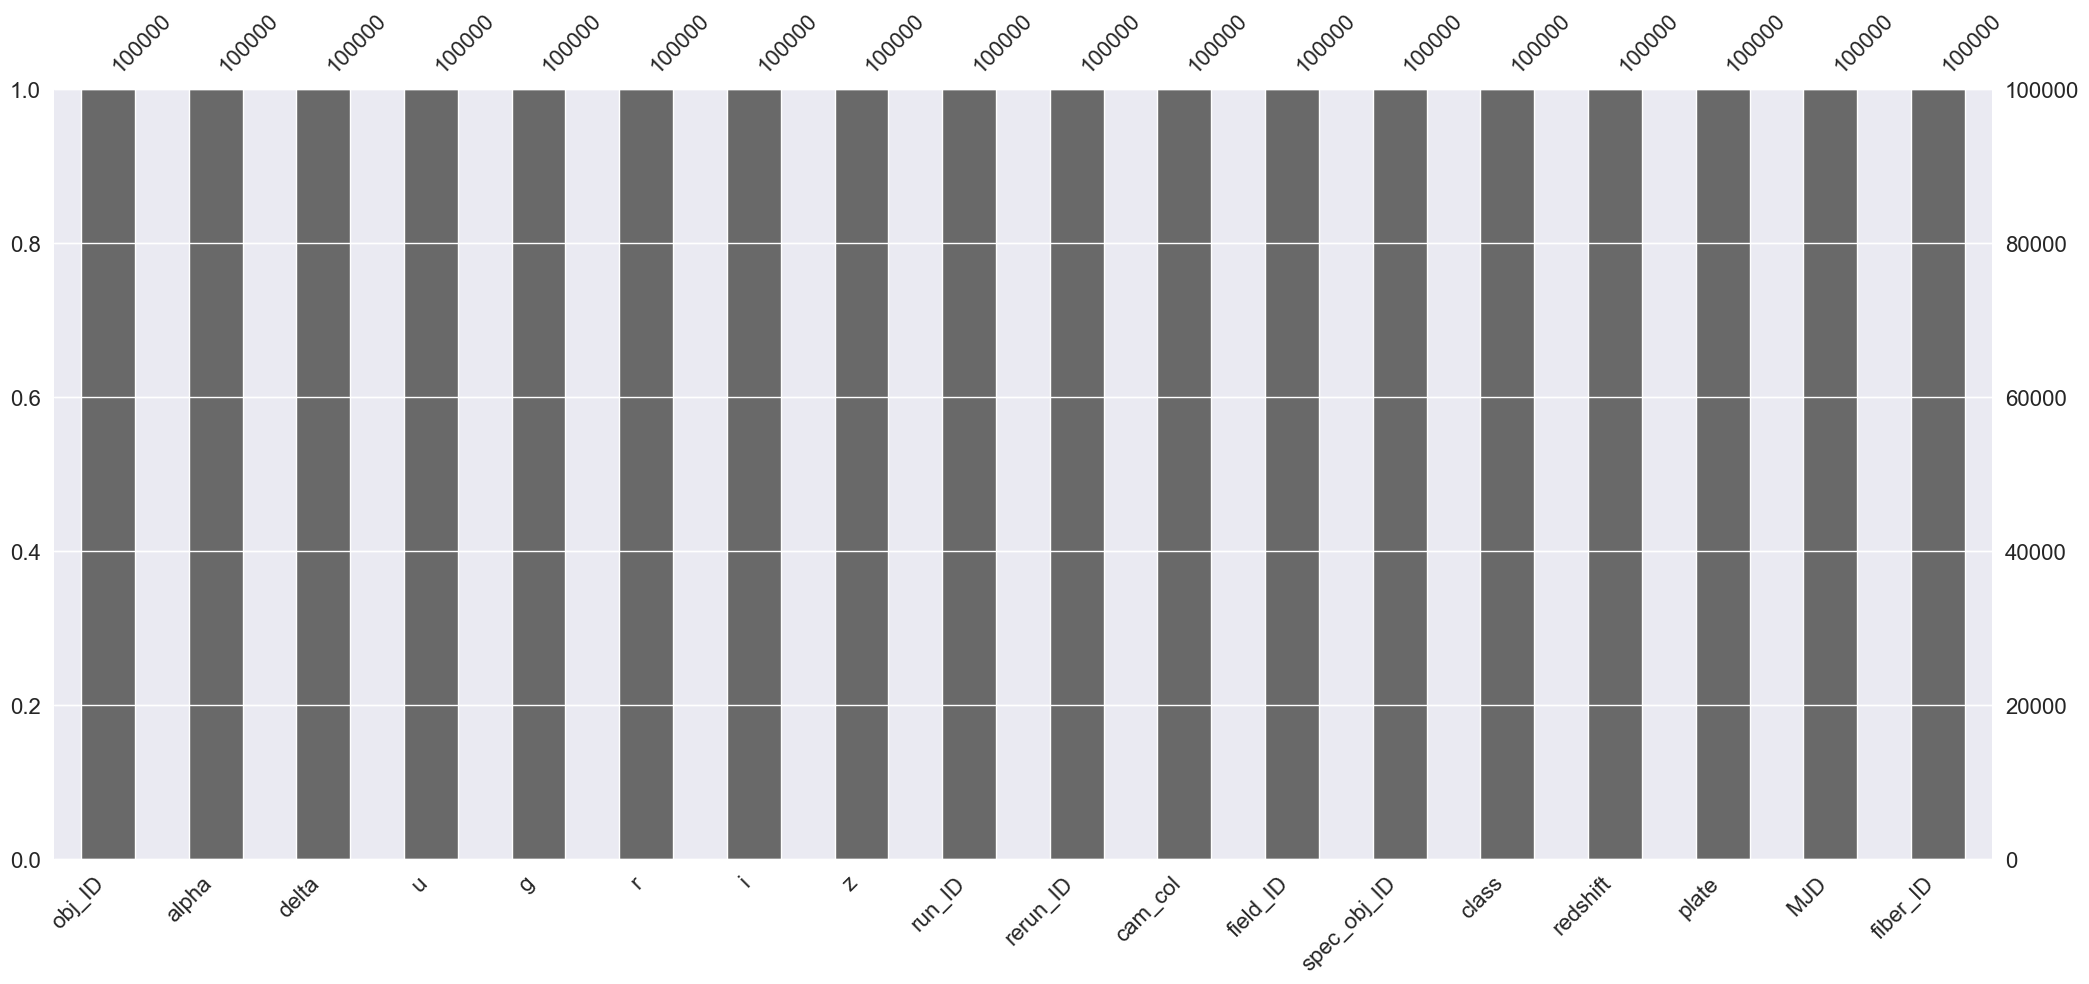

In [9]:
msno.bar(df)
plt.show()

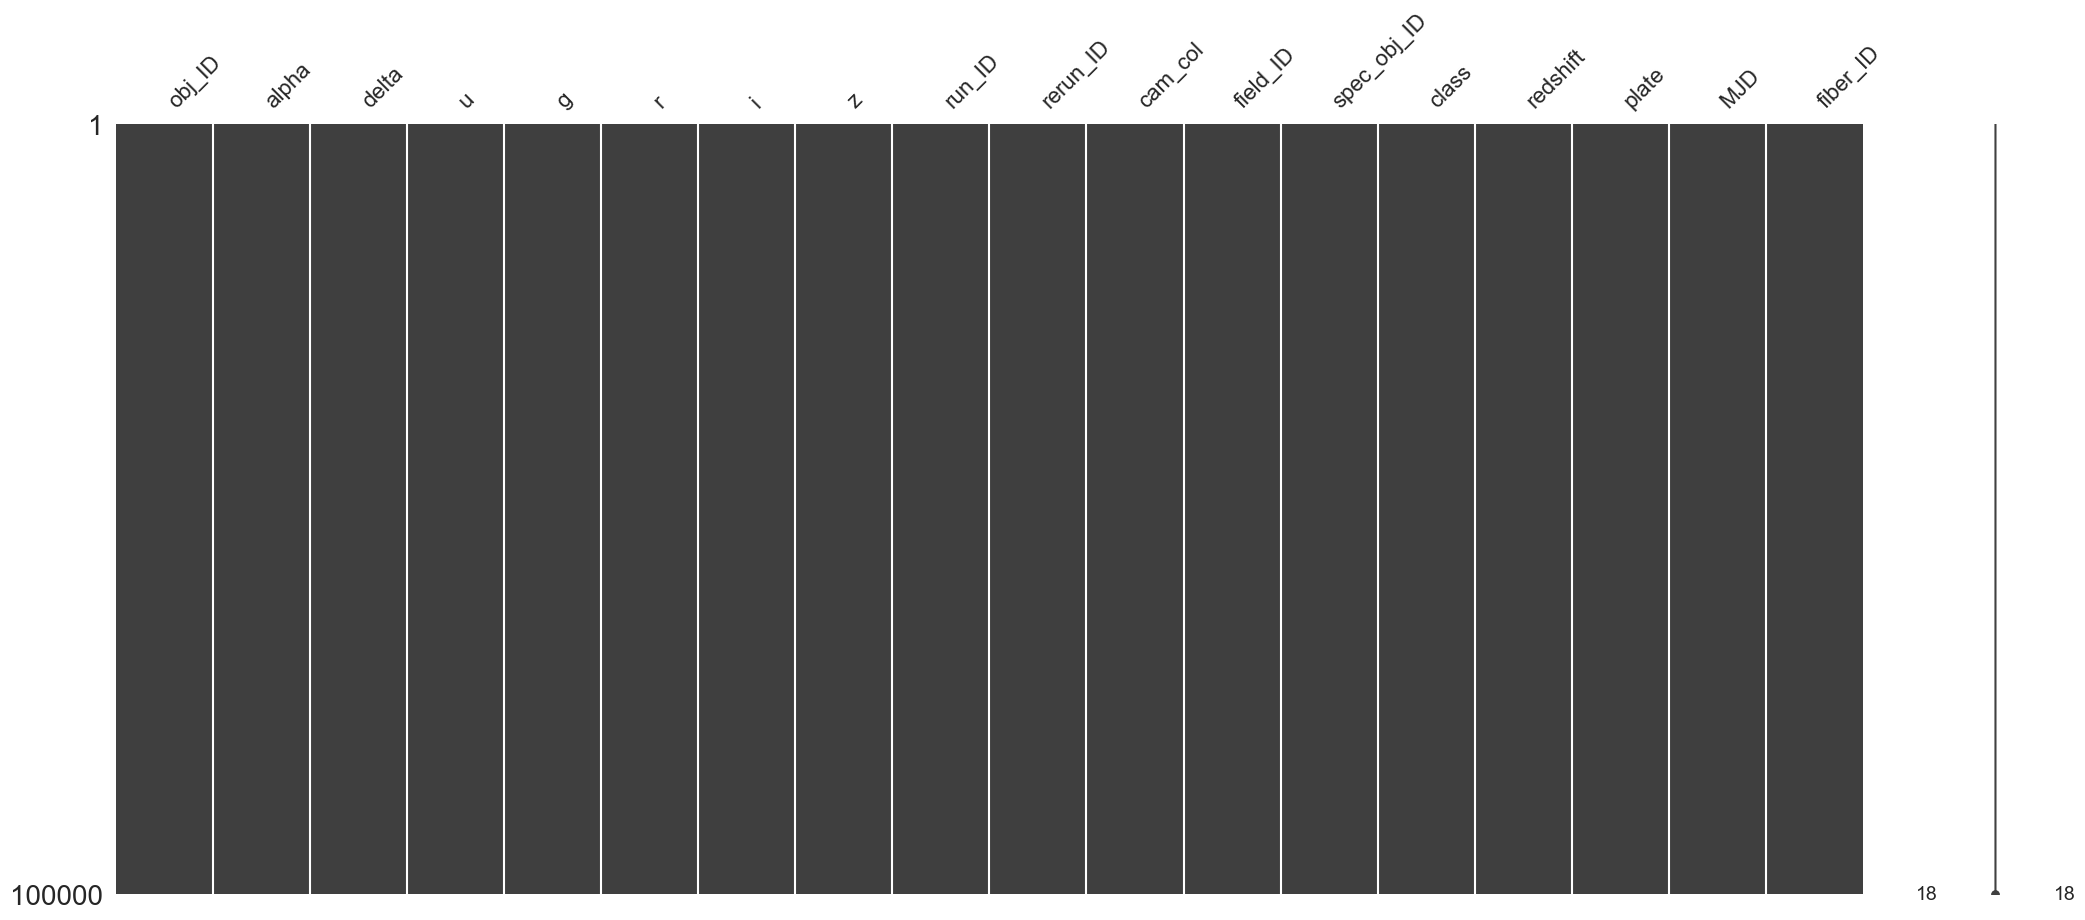

In [10]:
msno.matrix(df)
plt.show()

### Faltantes `-9999`

In [11]:
(df[["u", "g", "z"]] == -9999).sum()

u    1
g    1
z    1
dtype: int64

In [12]:
# Filas afectadas por al menos un faltante en u/g/z
mask_missings = (df[["u", "g", "z"]] == -9999).any(axis=1)
print(f"Filas con faltantes: {mask_missings.sum()}")
df[mask_missings].head()

Filas con faltantes: 1


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
79543,1.237649e+18,224.006526,-0.624304,-9999.0,-9999.0,18.1656,18.01675,-9999.0,752,301,2,537,3.731277e+18,STAR,0.000089,3314,54970,162


**Hallazgo:** el dataset llega limpio. No hay valores `NaN` declarados ni filas duplicadas. El único problema de calidad es una sola fila (clase STAR) que trae el dato `-9999` en `u`, `g` y `z`.

Como es solo un dato, es despreciable frente a las 100.000 observaciones. Optamos por eliminar esa fila en el preprocesamiento en lugar de imputarla.

In [13]:
df = df[~mask_missings].reset_index(drop=True)
print(f"Nuevo shape del DataFrame: {df.shape}")

Nuevo shape del DataFrame: (99999, 18)


# Análisis de las variables categóricas

In [14]:
df["class"] = df["class"].astype("category")
df["class"].value_counts()

class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64

In [15]:
df["class"].value_counts(normalize=True).round(3) * 100

class
GALAXY    59.4
STAR      21.6
QSO       19.0
Name: proportion, dtype: float64

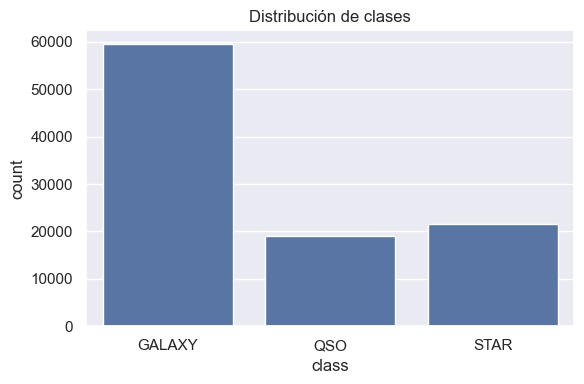

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="class", data=df, ax=ax)
ax.set_title("Distribución de clases")
plt.tight_layout(); plt.show()

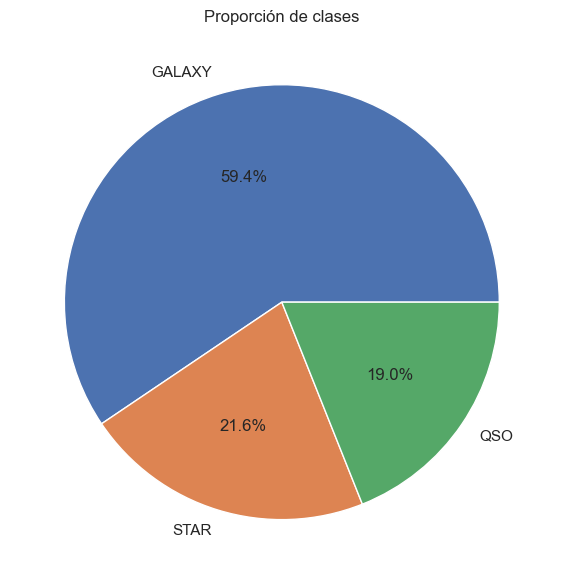

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = df["class"].value_counts()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%", shadow=False)
ax.set_title("Proporción de clases")
plt.tight_layout(); plt.show()

**Hallazgo:** las clases están desbalanceadas. Las galaxias dominan la muestra con cerca del 59,4%, mientras que las estrellas (21,6%) y los cuásares (19,0%) se reparten el resto de forma más pareja entre sí.

Este desbalance puede sesgar al modelo hacia la clase mayoritaria, así que lo tenemos que tener en cuenta al trabajar en la etapa de modelado.

# Análisis de las variables numéricas

Analizamos las variables físicas. Para cada una calculamos sus estadísticos descriptivos (media, mediana y moda) y la acompañamos con un histograma con líneas de referencia y un boxplot.

In [18]:
num_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift", "plate", "MJD"]
plot_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]

stats = pd.DataFrame({
    "media":   df[plot_cols].mean(),
    "mediana": df[plot_cols].median(),
    "moda":    df[plot_cols].mode().iloc[0],
    "std":     df[plot_cols].std(),
    "skew":    df[plot_cols].skew(),
}).round(4)
stats

,media,mediana,moda,std,skew
alpha,177.6287,180.9005,34.7496,96.5026,-0.0285
delta,24.1356,23.6465,-0.6019,19.6446,0.1751
u,22.0807,22.1791,24.6346,2.2511,-0.0703
g,20.6316,21.0999,25.1144,2.0374,-0.4280
r,19.6458,20.1253,24.8020,1.8548,-0.5079
i,19.0849,19.4052,24.3618,1.7579,-0.4042
z,18.7690,19.0046,22.8269,1.7660,-0.2568
redshift,0.5767,0.4242,0.0000,0.7307,2.5236


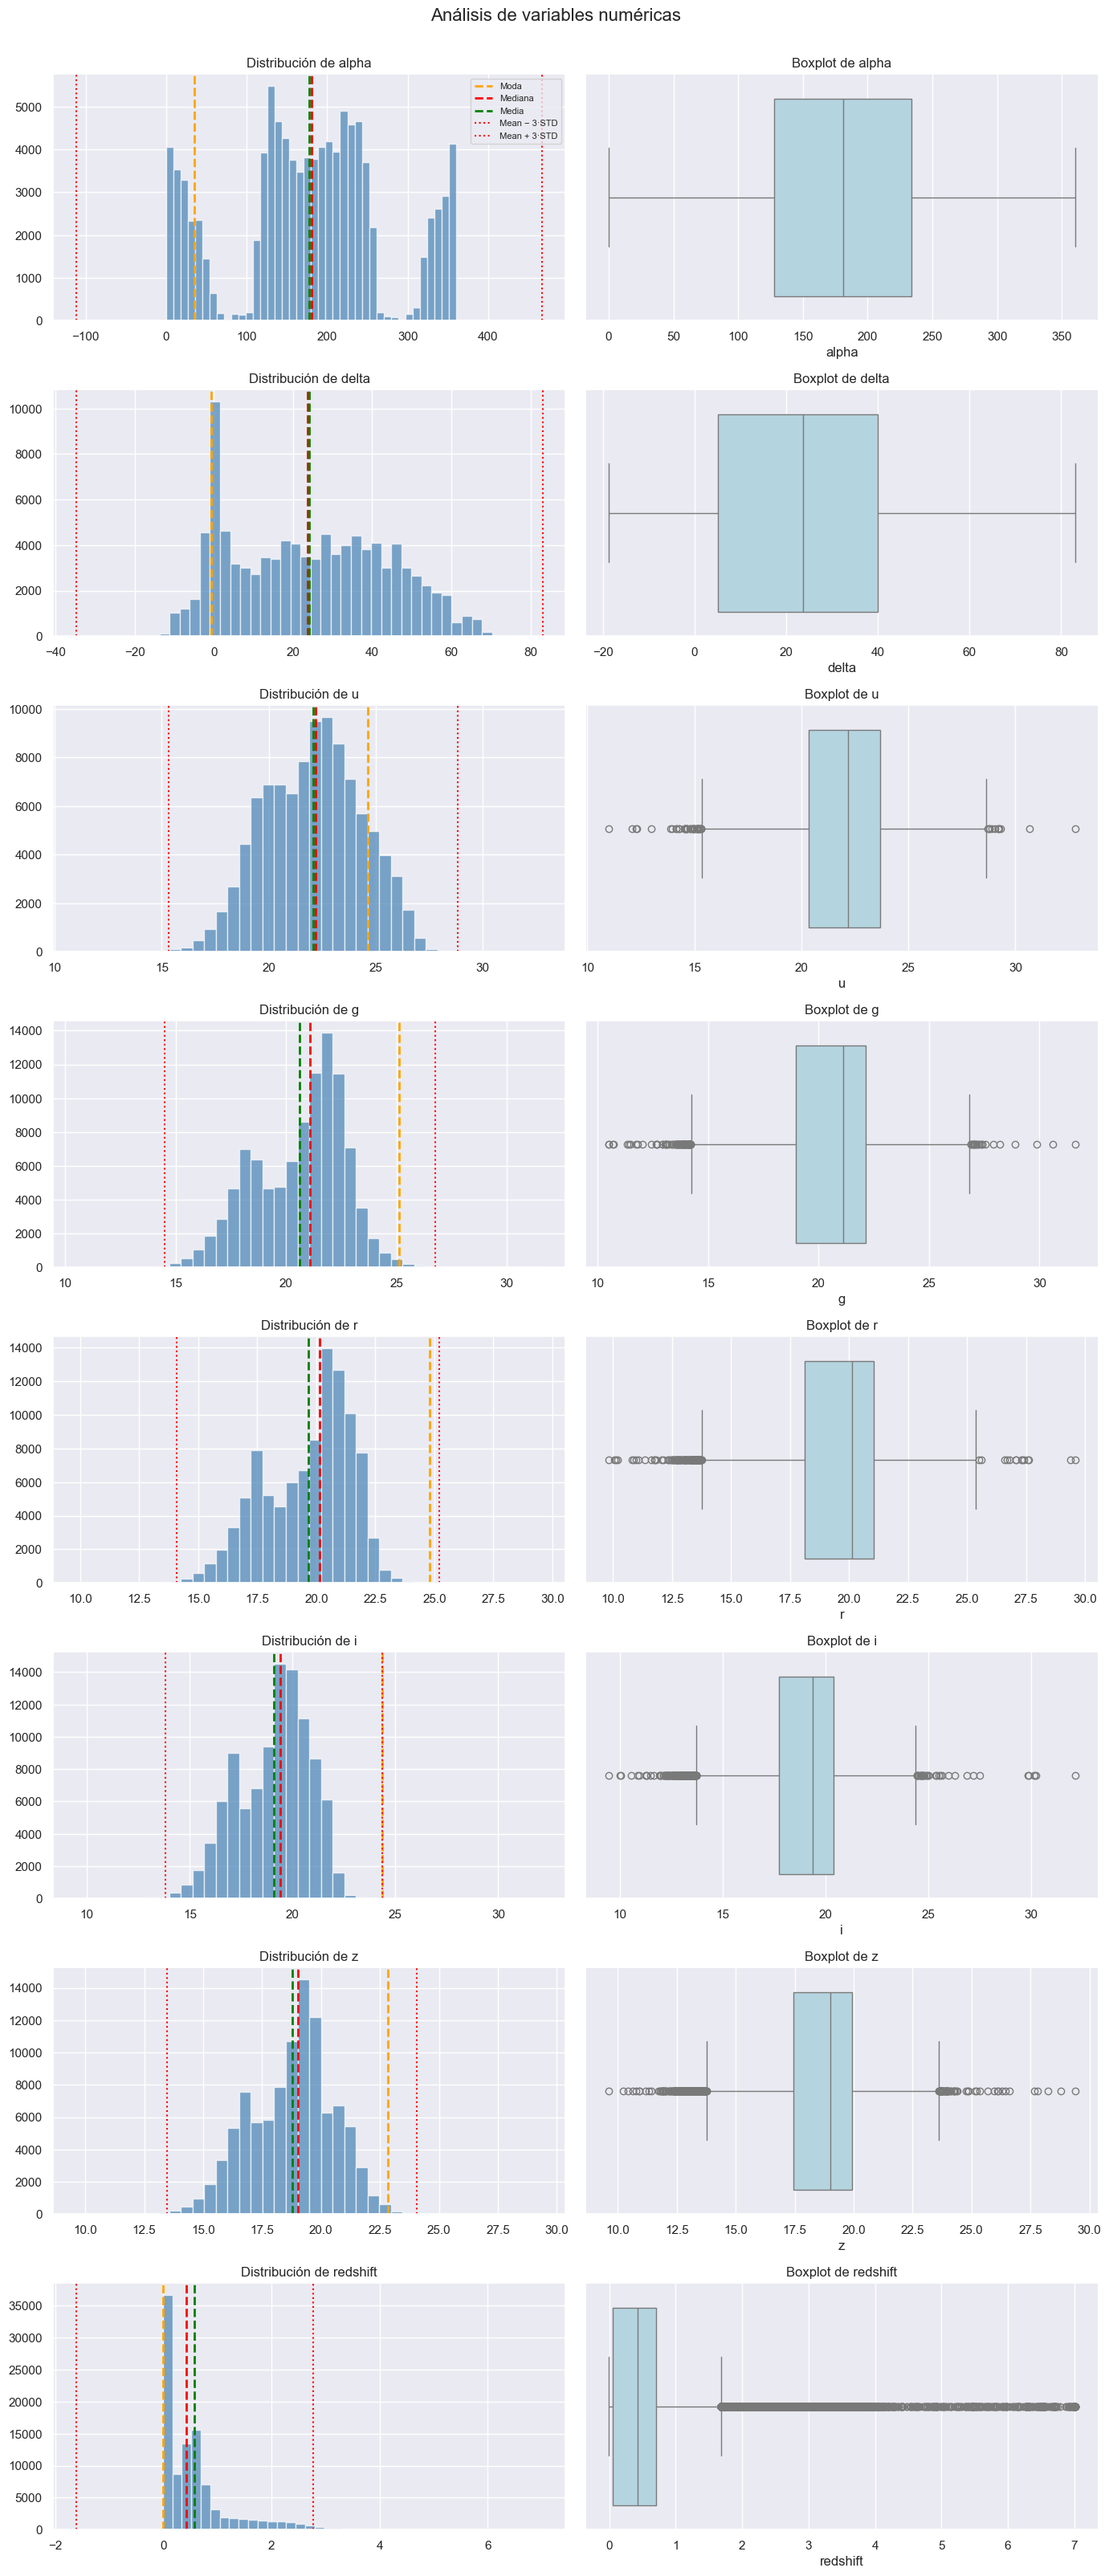

In [19]:
fig, axes = plt.subplots(len(plot_cols), 2, figsize=(14, 4 * len(plot_cols)))

for row, col in enumerate(plot_cols):
    serie = df[col]
    mean, std = serie.mean(), serie.std()

    ax_h = axes[row, 0]
    ax_h.hist(serie, bins=40, alpha=0.7, color="steelblue")
    ax_h.axvline(serie.mode().iloc[0], color="orange", ls="--", lw=2, label="Moda")
    ax_h.axvline(serie.median(),       color="red",    ls="--", lw=2, label="Mediana")
    ax_h.axvline(mean,                 color="green",  ls="--", lw=2, label="Media")
    ax_h.axvline(mean - 3 * std, color="red", ls=":", label="Mean \u2212 3\u00b7STD")
    ax_h.axvline(mean + 3 * std, color="red", ls=":", label="Mean + 3\u00b7STD")
    ax_h.set_title(f"Distribuci\u00f3n de {col}")
    if row == 0:
        ax_h.legend(fontsize=8)

    ax_b = axes[row, 1]
    sns.boxplot(x=serie, color="lightblue", ax=ax_b)
    ax_b.set_title(f"Boxplot de {col}")

fig.suptitle("An\u00e1lisis de variables num\u00e9ricas", fontsize=16, y=1.002)
plt.tight_layout()
plt.show()

**Observaciones de las distribuciones:**

- `alpha` (ascensión recta): la cobertura no es uniforme entre 0° y 360°, lo que refleja que el SDSS no abarca todo el cielo.
- `delta` (declinación): se concentra en valores positivos.
- `u`, `g`, `z`: distribuciones razonables, sin anomalías destacables.
- `r`, `i`: unimodales, con un leve sesgo hacia las magnitudes brillantes (en torno a 17 a 22).
- `redshift`: fuertemente sesgada a la derecha, con un pico cercano a 0 y una cola larga.

# Análisis bivariado por clase

### Distribuciones por clase (histogramas)

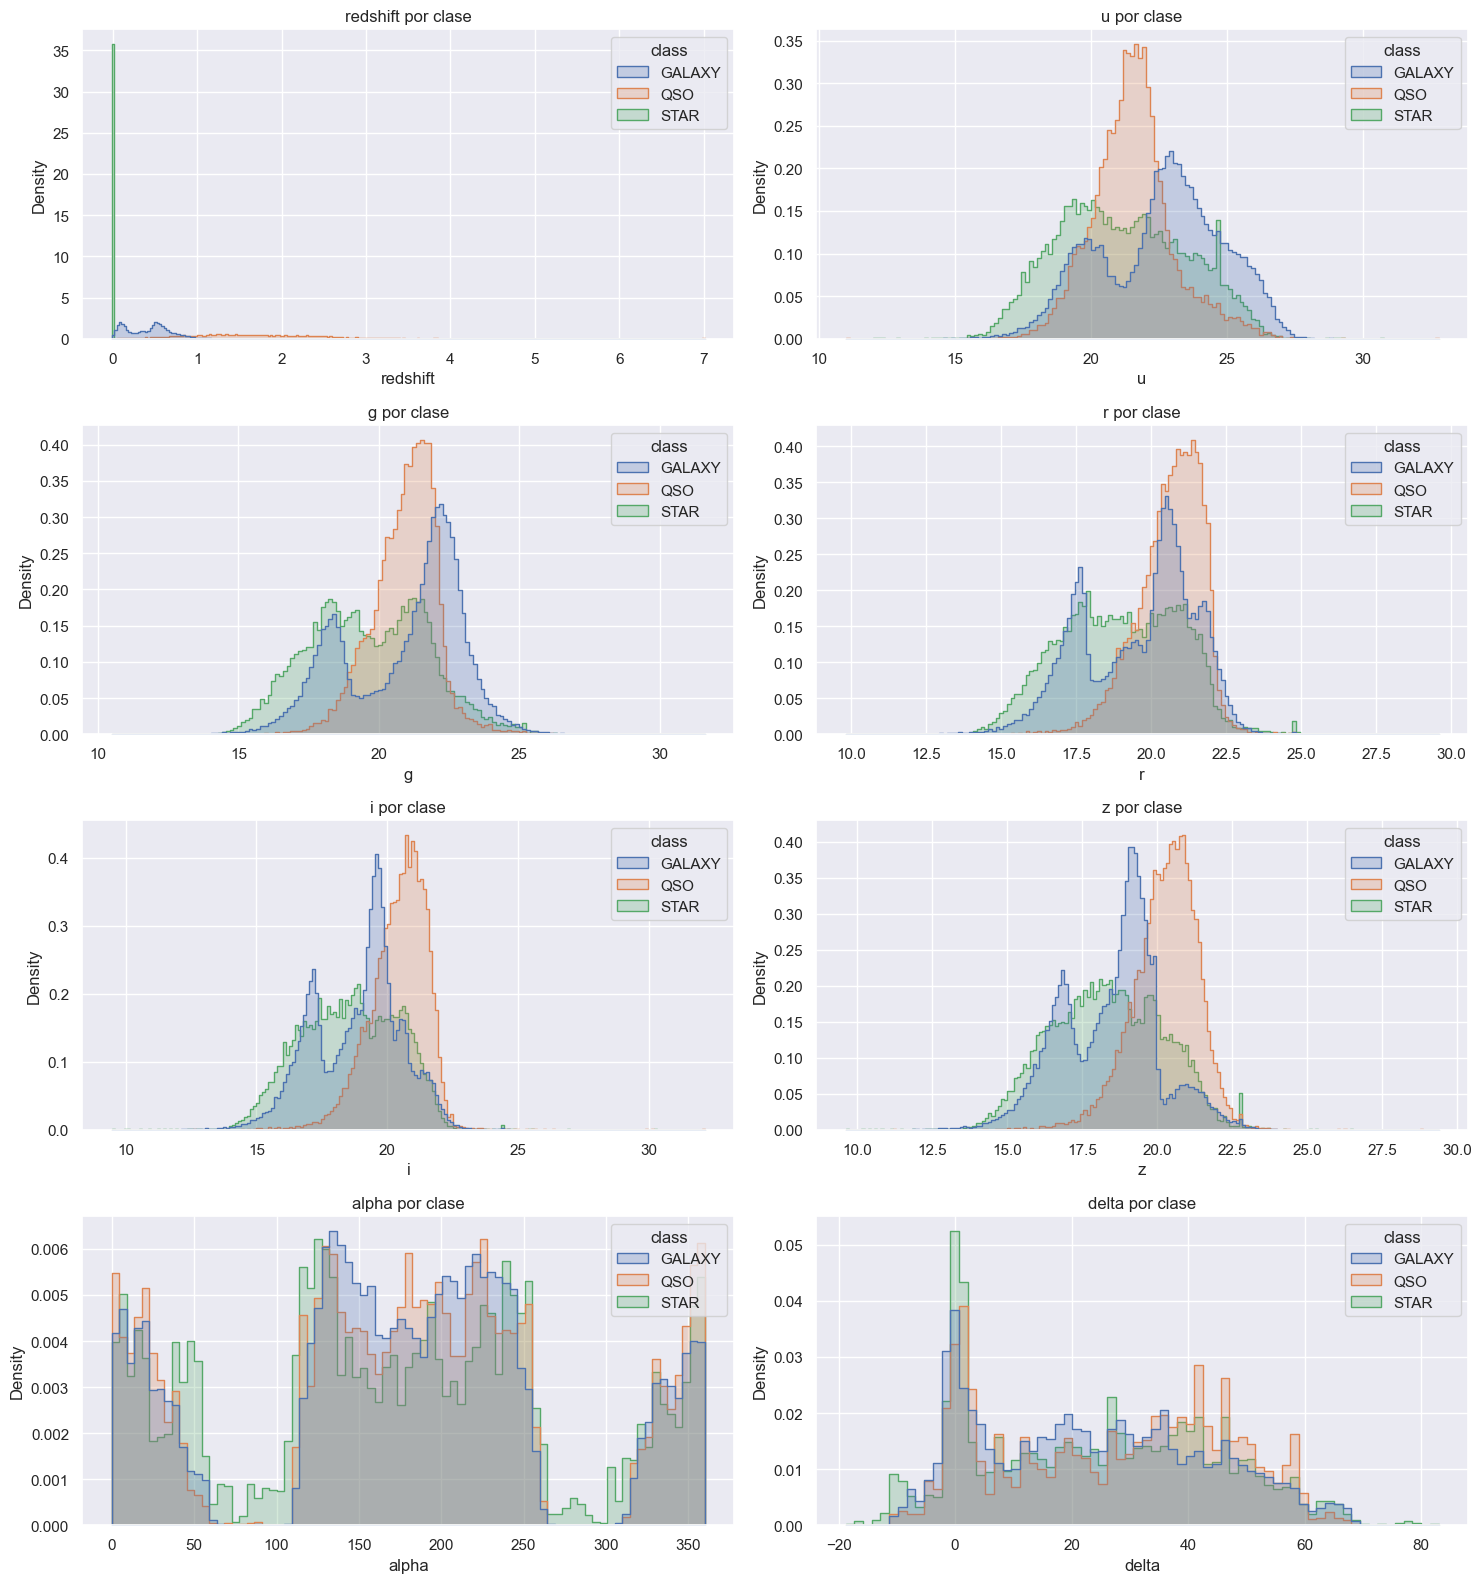

In [20]:
target_cols = ["redshift", "u", "g", "r", "i", "z", "alpha", "delta"]
df_plot = df.copy()

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
for ax, col in zip(axes.flat, target_cols):
    sns.histplot(data=df_plot, x=col, hue="class", element="step", stat="density",
                 common_norm=False, ax=ax)
    ax.set_title(f"{col} por clase")
plt.tight_layout(); plt.show()

## Análisis del redshift por clase

El primer histograma (arriba a la izquierda) separa la distribución del redshift según el tipo de objeto, y el contraste entre las tres clases es claro.

Las **estrellas** (STAR, en verde) tienen un redshift prácticamente nulo. Es lo esperable: pertenecen a nuestra propia galaxia y están muy cerca de nosotros. Las **galaxias** (GALAXY, en azul) concentran su densidad cerca de 0 y se extienden a lo sumo hasta un redshift de 1, así que las que detecta este estudio son relativamente cercanas. Los **cuásares** (QSO, en naranja) arrancan justo donde terminan las galaxias, alrededor de 1, y se distribuyen de forma casi plana entre 1 y 4 o más.

## ¿Por qué los cuásares alcanzan un redshift tan alto?

La respuesta combina dos factores. El primero es el brillo: una galaxia normal con redshift 3 o 4 es demasiado tenue para los telescopios convencionales, y por eso la curva azul cae a cero en ese rango. El núcleo de un cuásar, en cambio, es tan luminoso que sigue siendo visible después de viajar miles de millones de años luz.

El segundo factor es temporal. Como la luz tarda en llegar hasta nosotros, observar un objeto con redshift alto equivale a mirar el universo cuando era mucho más joven. Los cuásares eran frecuentes en el universo primitivo, hace unos 10.000 millones de años, mientras que las galaxias tranquilas y estables que vemos hoy (la curva azul) corresponden a épocas cósmicas más recientes.

## Las gráficas de magnitudes (u, g, r, i, z)

El resto de los paneles muestra los filtros de color, desde el ultravioleta `u` hasta el infrarrojo cercano `z`. En todos ellos la curva naranja (QSO) aparece desplazada hacia valores más altos del eje horizontal. Conviene recordar que en estas escalas un número mayor indica un objeto más tenue: pese a ser intrínsecamente muy luminosos, los cuásares se ven más débiles que las estrellas de nuestra galaxia porque se encuentran a distancias cosmológicas.

### Boxplots por clase

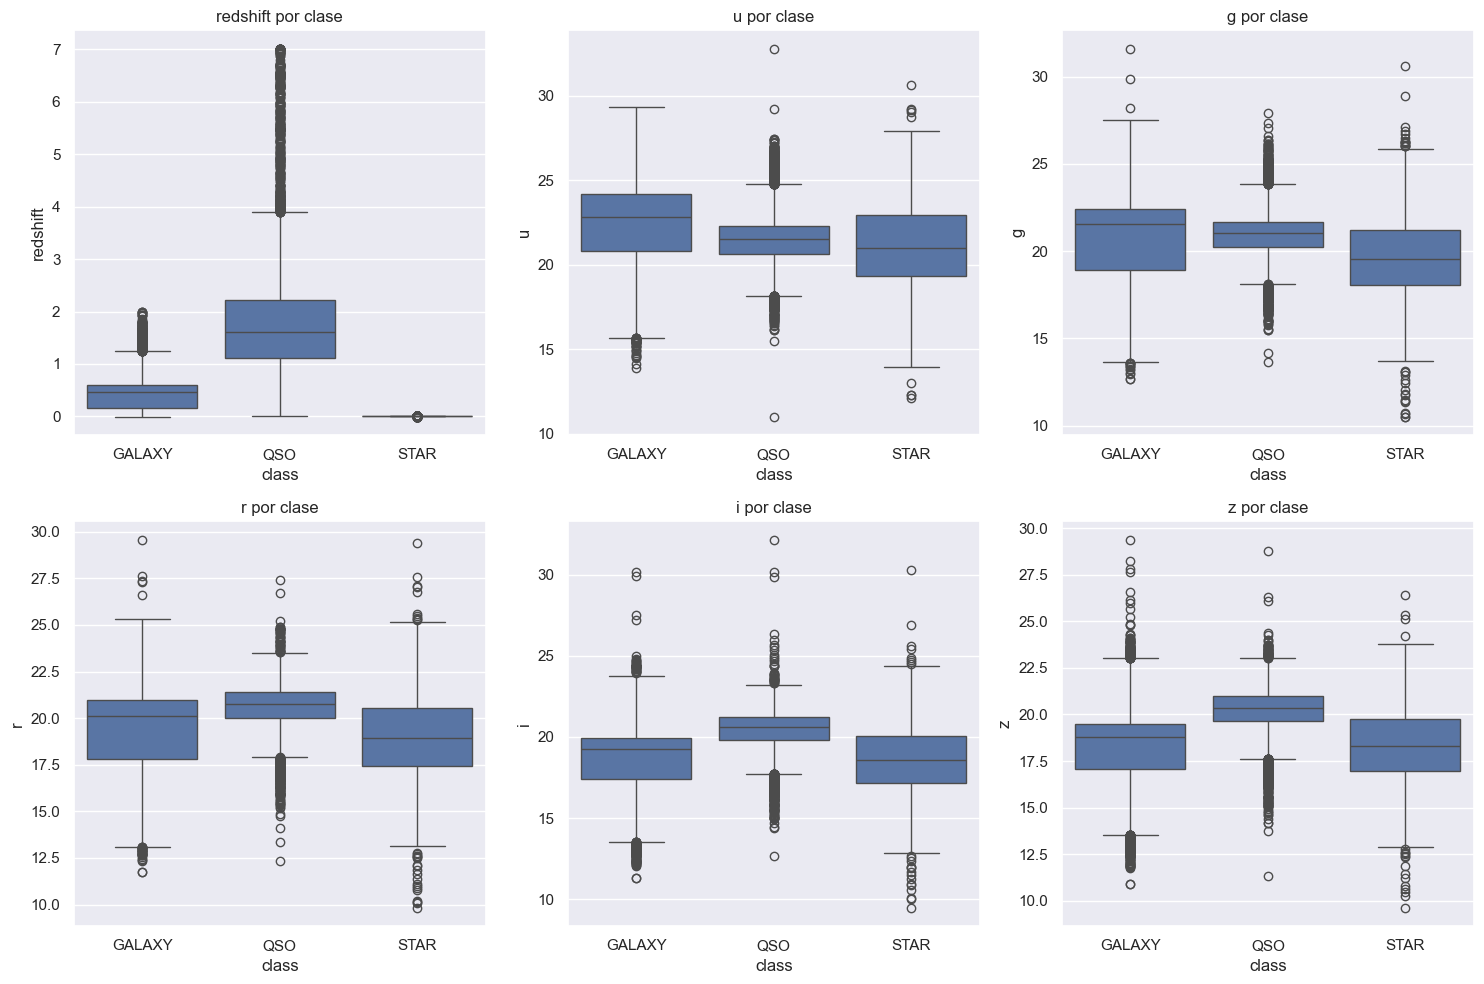

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, ["redshift", "u", "g", "r", "i", "z"]):
    sns.boxplot(data=df_plot, x="class", y=col, ax=ax)
    ax.set_title(f"{col} por clase")
plt.tight_layout(); plt.show()

**Hallazgos clave del análisis bivariado:**

- `redshift` es la variable que mejor separa las clases: las estrellas se concentran en torno a 0, las galaxias en valores intermedios de 0,05 a 0,5 y los cuásares en valores altos, de 0,5 a 7. Es, con diferencia, la **feature dominante**.
- Las magnitudes individuales (`u`, `g`, `r`, `i`, `z`) no separan las clases tan bien como `redshift`. En cambio, las **diferencias entre filtros** (los índices de color) sí lo hacen, y por eso las construimos en la sección de feature engineering.
- `alpha` y `delta` no aportan separación entre clases, algo esperable: la posición de un objeto en el cielo no determina su tipo.

### Mapa del cielo

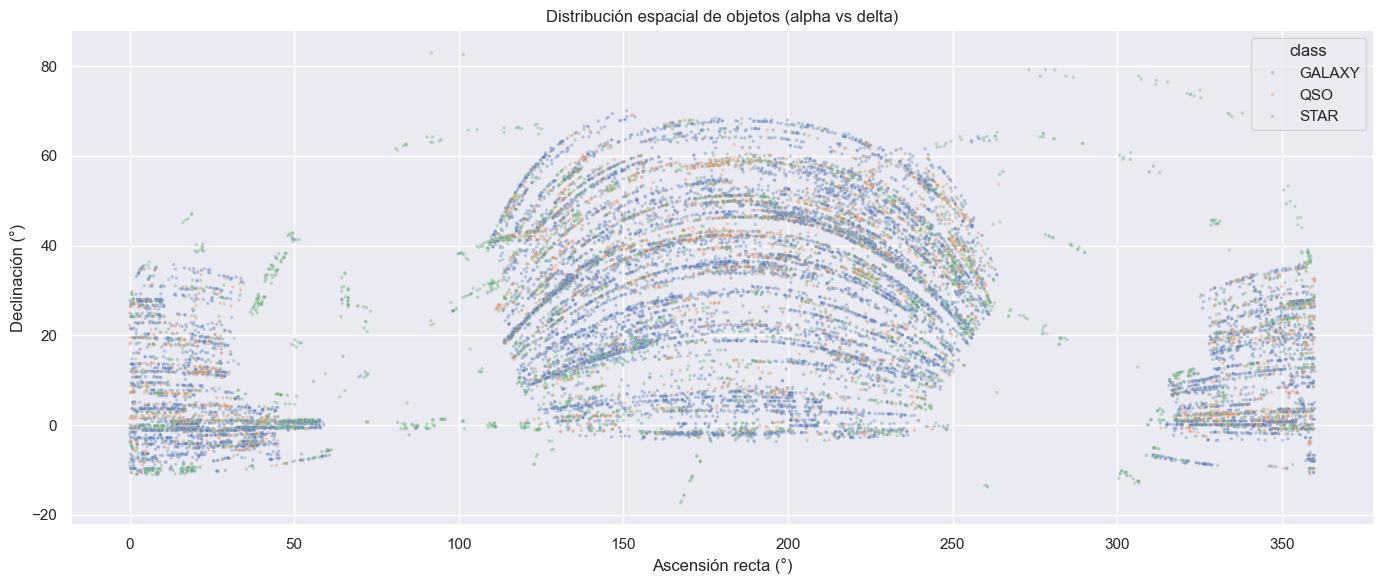

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.scatterplot(data=df.sample(20000, random_state=0),
                x="alpha", y="delta", hue="class",
                alpha=0.35, s=6, ax=ax)
ax.set_title("Distribución espacial de objetos (alpha vs delta)")
ax.set_xlabel("Ascensión recta (°)")
ax.set_ylabel("Declinación (°)")
plt.tight_layout(); plt.show()

**Hallazgo:** el mapa reproduce las regiones de muestreo características del SDSS. Dentro de las zonas cubiertas las tres clases aparecen mezcladas, lo que confirma que las coordenadas no son discriminantes por sí mismas.

# Análisis de outliers

Buscamos outliers con el criterio de rango intercuartil (IQR) usando un factor de 1,5 sobre las variables numéricas físicas. Reportamos el conteo por columna pero no eliminamos registros en esta etapa porque muchos outliers son astronómicamente reales: cuásares con redshift muy alto o estrellas particularmente brillantes que pertenecen legítimamente a la cola de la distribución.

In [23]:
def contar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return int(((serie < low) | (serie > high)).sum()), float(low), float(high)

filas = []
for col in num_cols:
    n_out, low, high = contar_outliers_iqr(df[col])
    filas.append({"variable": col, "outliers_iqr": n_out,
                  "limite_inf": round(low, 3), "limite_sup": round(high, 3)})

outliers_df = pd.DataFrame(filas).sort_values("outliers_iqr", ascending=False)
outliers_df

,variable,outliers_iqr,limite_inf,limite_sup
7,redshift,8989,-0.920,1.679
6,z,319,13.770,23.612
5,i,198,13.736,24.393
4,r,132,13.772,25.408
3,g,98,14.227,26.862
2,u,55,15.350,28.690
0,alpha,0,-32.048,393.461
1,delta,0,-46.984,92.033
8,plate,0,-4785.750,14712.250
9,MJD,0,50419.500,60591.500


# Análisis de correlaciones

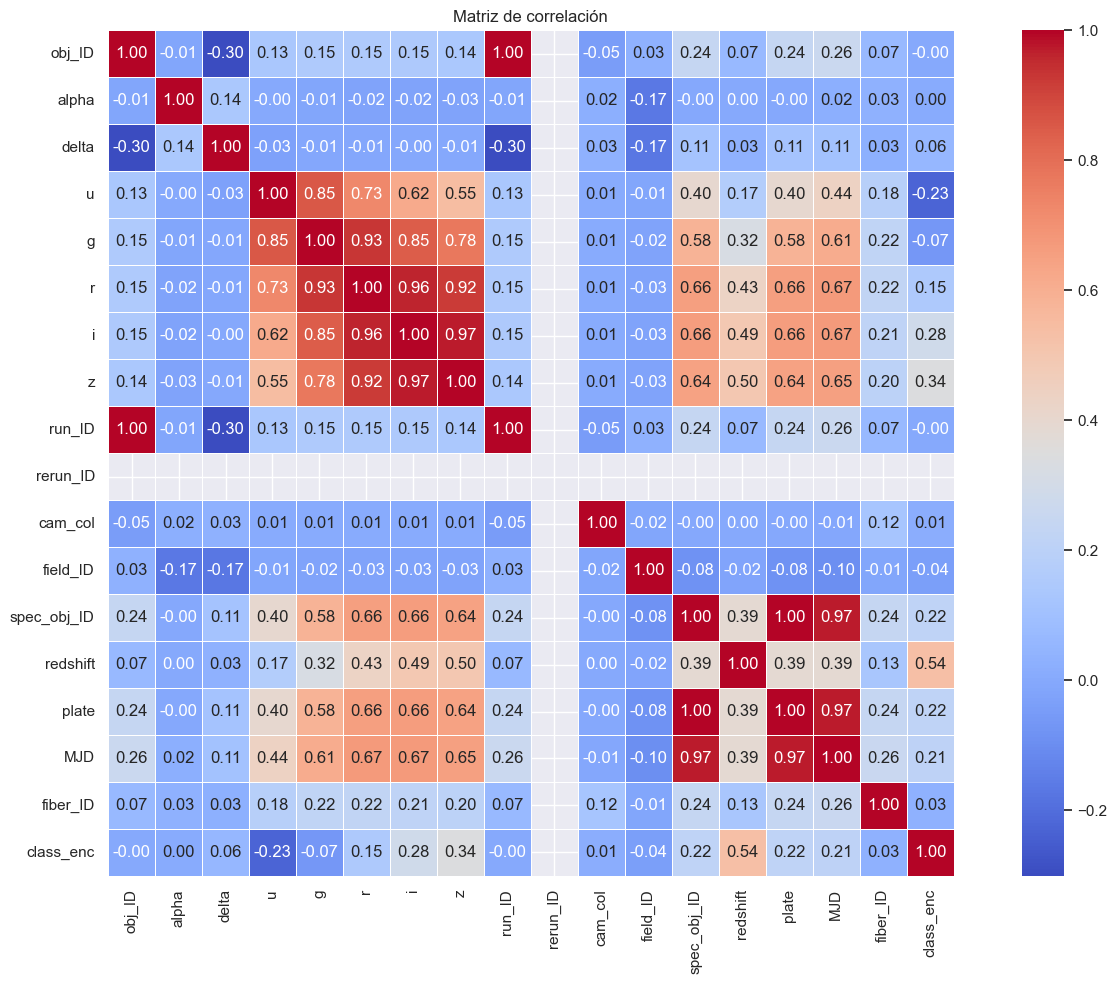

In [24]:
df_corr = df.copy()
df_corr["class_enc"] = df_corr["class"].map({"GALAXY": 0, "STAR": 1, "QSO": 2}).astype(int)

corr = df_corr.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout(); plt.show()

In [25]:
corr["class_enc"].drop("class_enc").sort_values()

u             -0.226930
g             -0.066894
field_ID      -0.038057
run_ID        -0.000039
obj_ID        -0.000038
alpha          0.004549
cam_col        0.014481
fiber_ID       0.032059
delta          0.056650
r              0.150696
MJD            0.207264
spec_obj_ID    0.215726
plate          0.215726
i              0.284400
z              0.340914
redshift       0.536829
rerun_ID            NaN
Name: class_enc, dtype: float64

**Hallazgos:**

- `redshift` presenta la correlación más alta con la clase (en torno a 0,54), en línea con lo que ya mostraba el análisis univariado.
- `plate`, `MJD` y `spec_obj_ID` también correlacionan con la clase, pero por sesgo de muestreo: ciertas campañas de observación se dedicaron a tipos concretos de objetos. No son variables físicas y usarlas implicaría riesgo de data leakage.
- `rerun_ID` devuelve `NaN` porque es constante: no aporta nada y se descarta.
- Las magnitudes `u`, `g`, `r`, `i` y `z` están fuertemente correlacionadas entre sí. 

# Feature engineering: índices de color

Los índices de color (`u-g`, `g-r`, `r-i`, `i-z`) son combinaciones clásicas en astronomía. Restan magnitudes en bandas contiguas, lo que aísla información espectral y tienden a separar las clases mejor que las magnitudes crudas.

In [26]:
df_color = df_plot[["u", "g", "r", "i", "z", "class"]].dropna().copy()
df_color["u_g"] = df_color["u"] - df_color["g"]
df_color["g_r"] = df_color["g"] - df_color["r"]
df_color["r_i"] = df_color["r"] - df_color["i"]
df_color["i_z"] = df_color["i"] - df_color["z"]

color_idx = ["u_g", "g_r", "r_i", "i_z"]
df_color[color_idx].describe().T

,count,mean,std,min,25%,50%,75%,max
u_g,99999.0,1.449096,1.179332,-12.74814,0.631245,1.32171,2.044565,18.62495
g_r,99999.0,0.985806,0.734675,-12.31861,0.379810,0.93146,1.577985,14.31517
r_i,99999.0,0.560912,0.501518,-14.64907,0.216320,0.47980,0.892205,12.20580
i_z,99999.0,0.315877,0.420396,-13.16249,0.134500,0.33803,0.474080,13.42710


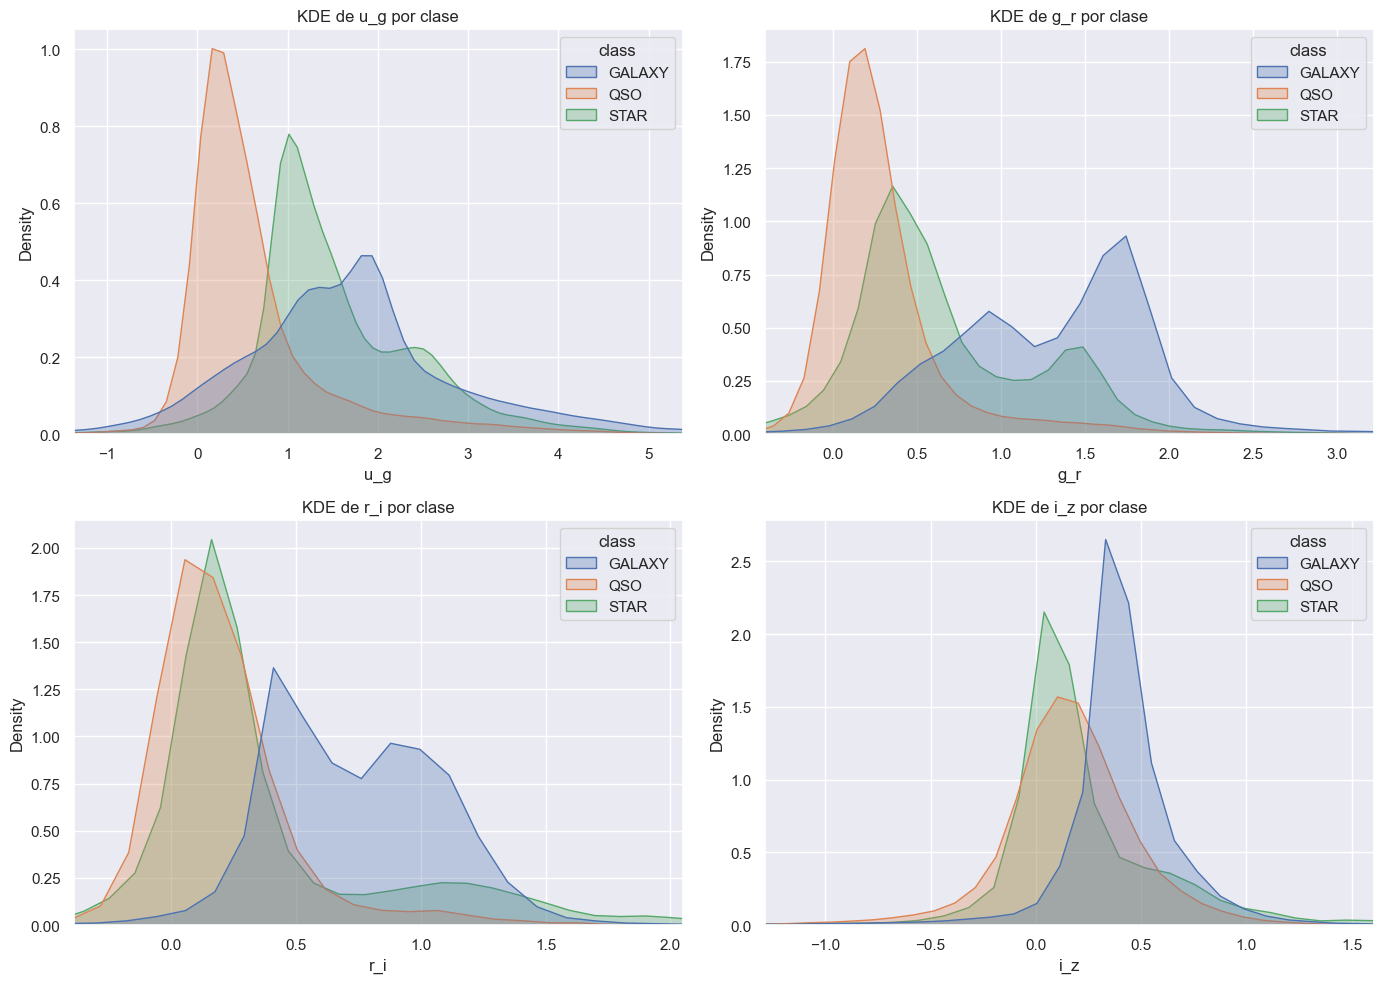

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, color_idx):
    sns.kdeplot(data=df_color, x=col, hue="class", common_norm=False,
                fill=True, alpha=0.3, ax=ax)
    ax.set_title(f"KDE de {col} por clase")
    ax.set_xlim(df_color[col].quantile(0.005), df_color[col].quantile(0.995))
plt.tight_layout(); plt.show()

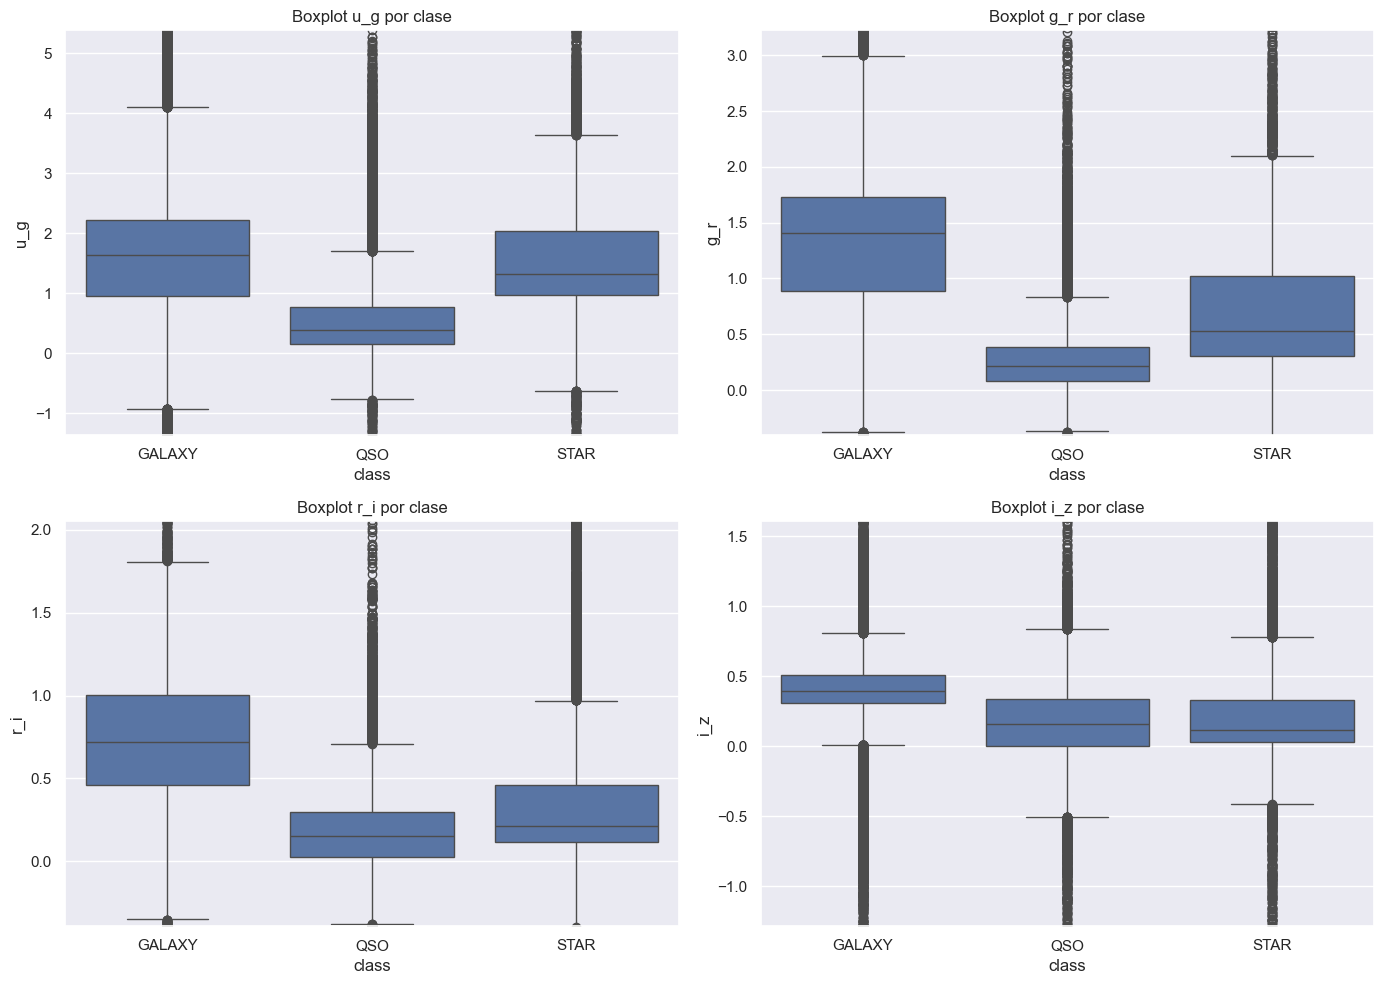

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, color_idx):
    sns.boxplot(data=df_color, x="class", y=col, ax=ax)
    ax.set_title(f"Boxplot {col} por clase")
    ax.set_ylim(df_color[col].quantile(0.005), df_color[col].quantile(0.995))
plt.tight_layout(); plt.show()

**Hallazgo:** los índices de color muestran separabilidad por clase, sobre todo `u_g` y `g_r`. Los incorporamos como features derivadas para el modelo.

# Columnas de identificadores

In [29]:
id_cols = ["obj_ID", "run_ID", "rerun_ID", "cam_col", "field_ID",
           "spec_obj_ID", "fiber_ID", "plate", "MJD"]
df[id_cols].nunique().sort_values()

rerun_ID           1
cam_col            6
run_ID           430
field_ID         856
fiber_ID        1000
MJD             2180
plate           6284
obj_ID         78052
spec_obj_ID    99999
dtype: int64

**Hallazgos:**

- `rerun_ID`: un único valor, es constante y lo descartamos.
- `cam_col`: 6 valores, categórica que indica la columna de la cámara.
- `obj_ID`, `spec_obj_ID`: un identificador distinto por fila, sin valor predictivo. Los descartamos.
- `run_ID`, `field_ID`, `fiber_ID`: identificadores técnicos de la adquisición, sin contenido físico. También los descartamos.
- `plate` y `MJD`: correlacionan con la clase, pero solo por el sesgo de muestreo, no porque describan al objeto. Las descartamos para no introducir data leakage.

### Validación de `spec_obj_ID`

La documentación del SDSS indica que dos observaciones con el mismo `spec_obj_ID` deben compartir la misma `class`. Verificamos que esa restricción se cumpla y, de paso, contamos cuántos `spec_obj_ID` aparecen repetidos.

In [30]:
spec_counts = df["spec_obj_ID"].value_counts()
print(f"spec_obj_ID totales:     {len(spec_counts)}")
print(f"spec_obj_ID únicos:      {(spec_counts == 1).sum()}")
print(f"spec_obj_ID repetidos:   {(spec_counts > 1).sum()}")
print(f"Máx. repeticiones:       {spec_counts.max()}")

spec_obj_ID totales:     99999
spec_obj_ID únicos:      99999
spec_obj_ID repetidos:   0
Máx. repeticiones:       1


**Resultado:** todos los `spec_obj_ID` son únicos, una sola fila por identificador. Al no haber repeticiones, la restricción de "clases compartidas" no llega a aplicar en este subset de 100k filas. Confirmamos además que `spec_obj_ID` es un identificador único sin valor predictivo, así que lo descartamos.

# Pairplot reducido

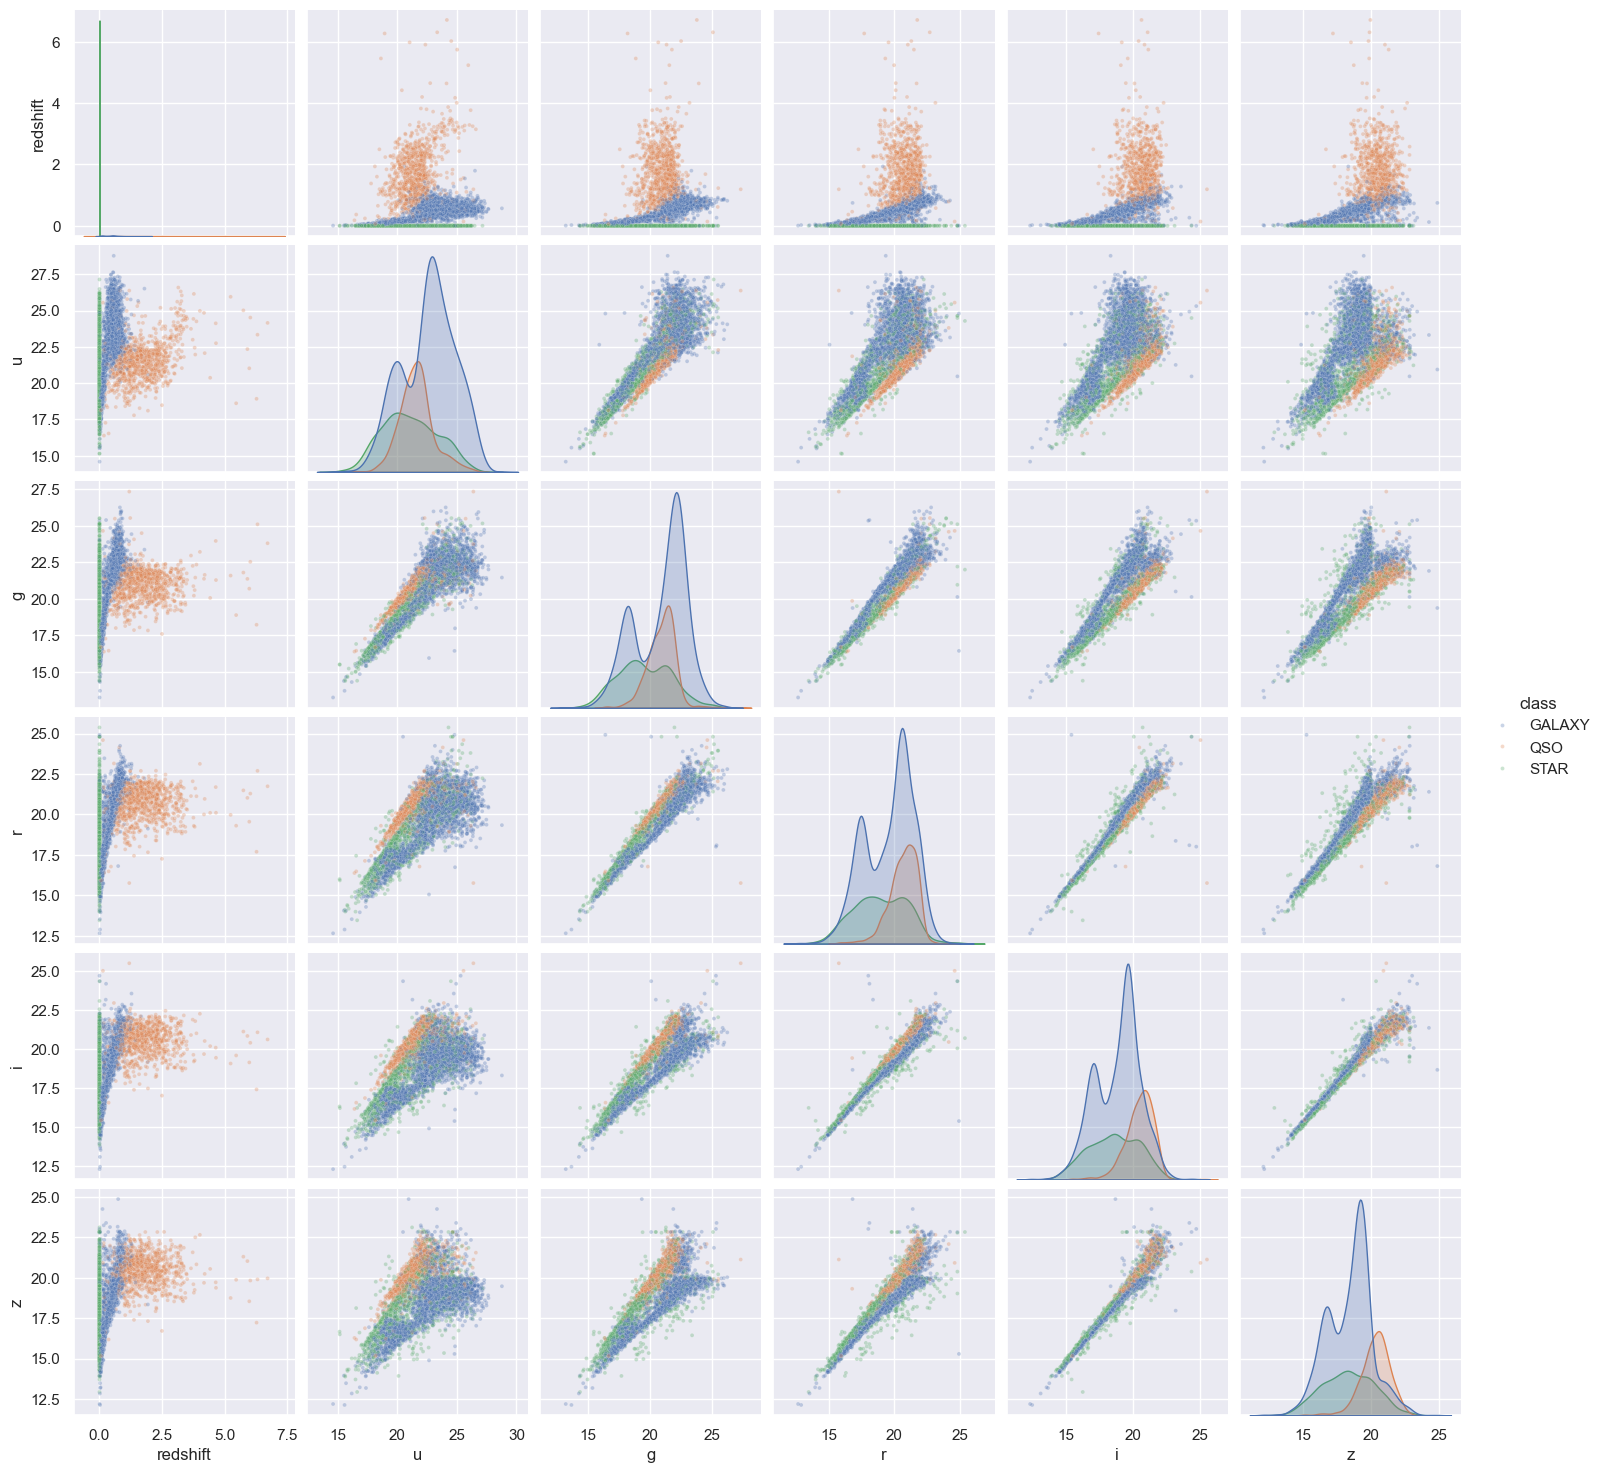

In [31]:
sample = df_plot[["redshift", "u", "g", "r", "i", "z", "class"]].dropna().sample(5000, random_state=0)
sns.pairplot(sample, hue="class", diag_kind="kde", plot_kws={"alpha": 0.3, "s": 8})
plt.show()

**Hallazgo:** el pairplot confirma que `redshift` es la variable más discriminante. Las magnitudes por separado se solapan bastante entre clases, pero al combinarse entre sí dejan ver una estructura que se puede usar.

## Hallazgos principales del EDA

- **Tamaño y target:** 100.000 filas, con target `class` ∈ {GALAXY, STAR, QSO}.
- **Desbalance de clases:** GALAXY ~59%, STAR ~22% y QSO ~19%. Lo manejamos con pesos de clase.
- **Calidad de datos:** no hay `NaN` ni duplicados. Una única fila tiene el centinela `-9999` en `u`, `g` y `z`, y la eliminamos.
- **Variable dominante:** `redshift` es con diferencia la feature más informativa, con una correlación cercana a 0,54 con la clase. Esto respalda la hipótesis física que planteamos en la sección 1.2.
- **Magnitudes:** `u`, `g`, `r`, `i` y `z` están muy correlacionadas entre sí, así que los índices de color (`u-g`, `g-r`, `r-i`, `i-z`) aportan separabilidad adicional.
- **Columnas que descartamos** por no tener valor físico o por riesgo de data leakage: `rerun_ID` (constante); `obj_ID`, `spec_obj_ID`, `run_ID`, `field_ID`, `fiber_ID` y `cam_col` (identificadores); `plate` y `MJD` (correlacionan por el sesgo temporal de muestreo).
- **Coordenadas (`alpha`, `delta`):** no separan clases; solo reflejan la cobertura del relevamiento.
- **Outliers:** algunos son astronómicamente reales (QSO lejanos o estrellas muy brillantes), así que no los eliminamos.

Con esto cerramos el análisis exploratorio y pasamos a la preparación de datos, el baseline, el modelado y la evaluación.

# 3. Preparación de datos y *feature engineering*

Llevamos al dataset las decisiones que surgieron del EDA. El procedimiento es directo:

1. **Eliminar** la única fila con el centinela `-9999`.
2. **Descartar** las columnas sin valor físico o con riesgo de *data leakage* (identificadores, `plate`, `MJD`).
3. **Crear índices de color** (`u-g`, `g-r`, `r-i`, `i-z`): diferencias entre filtros que resumen la forma del espectro.
4. **Codificar** el target con `LabelEncoder`.
5. **Un único `train_test_split` estratificado** (80/20), que reutilizan *todos* los modelos para que la comparación sea justa. El conjunto de test queda intacto hasta la evaluación final, lo que evita *data leakage*.

Para poner a prueba la hipótesis central definimos dos conjuntos de features:

- **`with_z`**: magnitudes, índices de color, coordenadas y **`redshift`**.
- **`without_z`**: lo mismo, pero **sin `redshift`**.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler

# --- 1) Cargar limpio y eliminar la fila -9999 (u/g/z) ---
df_model = pd.read_csv("star_classification.csv")
print(f"Shape original: {df_model.shape}")
mask_missings = (df_model[["u", "g", "z"]] == -9999).any(axis=1)
df_model = df_model[~mask_missings].copy()
print(f"Shape tras eliminar filas con faltantes: {df_model.shape}")

# --- 2) Descartar identificadores y columnas con leakage ---
drop_cols = ["obj_ID", "spec_obj_ID", "run_ID", "rerun_ID", "cam_col",
             "field_ID", "fiber_ID", "plate", "MJD"]
df_model = df_model.drop(columns=drop_cols)
print(f"Shape tras eliminar columnas: {df_model.shape}")

# --- 3) Índices de color (diferencias entre filtros) ---
df_model["u_g"] = df_model["u"] - df_model["g"]
df_model["g_r"] = df_model["g"] - df_model["r"]
df_model["r_i"] = df_model["r"] - df_model["i"]
df_model["i_z"] = df_model["i"] - df_model["z"]
print(f"Shape tras agregar índices de color: {df_model.shape}")

# --- 4) Codificar el target ---
le = LabelEncoder()
y = le.fit_transform(df_model["class"])
class_names = list(le.classes_)
print(f"Clases: {dict(enumerate(class_names))}")

# --- Conjuntos de features ---
mags    = ["u", "g", "r", "i", "z"]
colors  = ["u_g", "g_r", "r_i", "i_z"]
coords  = ["alpha", "delta"]
FEATURES = {
    "with_z":    mags + colors + coords + ["redshift"],
    "without_z": mags + colors + coords,
}

# --- 5) Split estratificado único, reutilizado por todos los modelos ---
X_all = df_model[FEATURES["with_z"]].copy()       # superset; cada modelo elige sus columnas
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_all, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"\nTrain: {X_train_full.shape[0]} filas | Test: {X_test_full.shape[0]} filas")
print(f"Proporción de clases (train): {np.round(np.bincount(y_train) / len(y_train), 3)}")
print(f"Proporción de clases (test): {np.round(np.bincount(y_test) / len(y_test), 3)}")

# --- 6) RandomUnderSampler para balancear el set de entrenamiento
undersample = RandomUnderSampler(random_state=SEED)
X_train_full, y_train = undersample.fit_resample(X_train_full, y_train)

print(f"\n-- Muestra de Entrenamiento Reducido para Balancear Clases --")
print(f"\nTrain: {X_train_full.shape[0]} filas | Test: {X_test_full.shape[0]} filas")
print(f"Proporción de clases (train): {np.round(np.bincount(y_train) / len(y_train), 3)}")

Shape original: (100000, 18)
Shape tras eliminar filas con faltantes: (99999, 18)
Shape tras eliminar columnas: (99999, 9)
Shape tras agregar índices de color: (99999, 13)
Clases: {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}

Train: 79999 filas | Test: 20000 filas
Proporción de clases (train): [0.594 0.19  0.216]
Proporción de clases (test): [0.594 0.19  0.216]

-- Muestra de Entrenamiento Reducido para Balancear Clases --

Train: 45507 filas | Test: 20000 filas
Proporción de clases (train): [0.333 0.333 0.333]


# Análisis ANOVA

In [33]:

# ANOVA (numéricas, fit en train, transformar ambos)

from sklearn.feature_selection import SelectKBest, f_classif

selector_anova = SelectKBest(score_func=f_classif, k='all') # se puede usar f_regression cuando la v.a. target es numérica
X_train_num_best = selector_anova.fit_transform(X_train_full[FEATURES["with_z"]], y_train)

selected_indices = selector_anova.get_support() # Esta función me devuelve los features seleccionados
selected_features = X_train_full[FEATURES["with_z"]].columns[selected_indices]
p_values = selector_anova.pvalues_[selected_indices]
scores = selector_anova.scores_[selected_indices]

print(f"Numéricas antes de filtrar: {X_train_full[FEATURES["with_z"]].columns.tolist()}")
print("\nCaracterísticas seleccionadas (ANOVA):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")

print("\nP-valores de todas las características:")
for feature, p_valor in zip(X_train_full[FEATURES["with_z"]].columns, p_values):
    print(f"{feature}: {p_valor}")

Numéricas antes de filtrar: ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z', 'alpha', 'delta', 'redshift']

Características seleccionadas (ANOVA):
u: 1905.7723
g: 2512.4345
r: 3823.2403
i: 6318.6003
z: 7268.0947
u_g: 4847.5191
g_r: 11798.6935
r_i: 4999.6225
i_z: 1197.4265
alpha: 18.2979
delta: 142.6534
redshift: 40211.0577

P-valores de todas las características:
u: 0.0
g: 0.0
r: 0.0
i: 0.0
z: 0.0
u_g: 0.0
g_r: 0.0
r_i: 0.0
i_z: 0.0
alpha: 1.1389671045622013e-08
delta: 1.7371534810252721e-62
redshift: 0.0


Con el resultado del Análisis de ANOVA podemos ver que la feature que mas aporta es el `redshift`, lo cuál, representa un data-leakage. Esto confirma lo visto en el análisis EDA. por ello realizamos el entrenamiento con y sin `redshift`

# 4. Heurística baseline

Antes de entrenar cualquier modelo fijamos un **baseline**: la referencia que los modelos deben superar para justificar su complejidad.

Usamos **dos baselines**, de menor a mayor sofisticación:

1. **Predecir clase mayoritaria** (`DummyClassifier`): predecir siempre la clase mas frecuente (GALAXY).
2. **Heurística por umbral de `redshift`** (derivada del EDA): aprovecha el predictor dominante con dos cortes simples.
   - $z < 0{,}004 \Rightarrow$ **STAR** (redshift ≈ 0, objeto cercano).
   - $0{,}004 \le z < 1{,}0 \Rightarrow$ **GALAXY** (distancia intermedia).
   - $z \ge 1{,}0 \Rightarrow$ **QSO** (muy lejano).

La métrica principal es **F1-macro**: calcula F1 por clase y promedia las tres sin ponderar por frecuencia. Cada clase pesa igual. 

Como las clases están desbalanceadas, promediar las tres por igual evita que el rendimiento sobre la clase mayoritaria oculte un mal desempeño en las minoritarias.

In [34]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Registro de resultados: lo van completando baseline y modelos para la tabla comparativa final
resultados = []

def registrar(nombre, y_true, y_pred):
    """Calcula métricas y las agrega al registro global `resultados`."""
    fila = {
        "modelo": nombre,
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    }
    resultados.append(fila)
    print(f"{nombre:32s} | F1-macro={fila['f1_macro']:.4f} | acc={fila['accuracy']:.4f}")
    return fila

In [35]:
from sklearn.dummy import DummyClassifier

code_of = {name: i for i, name in enumerate(class_names)}  # {'GALAXY': 0, 'QSO': 1, 'STAR': 2}

# --- Baseline 1: clase mayoritaria ---
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train_full, y_train)
registrar("Baseline: clase mayoritaria", y_test, dummy.predict(X_test_full))

print("\nReporte de la heurística por clase mayoritaria:\n")
print(classification_report(y_test, dummy.predict(X_test_full), target_names=class_names))

Baseline: clase mayoritaria      | F1-macro=0.2485 | acc=0.5945

Reporte de la heurística por clase mayoritaria:

              precision    recall  f1-score   support

      GALAXY       0.59      1.00      0.75     11889
         QSO       0.00      0.00      0.00      3792
        STAR       0.00      0.00      0.00      4319

    accuracy                           0.59     20000
   macro avg       0.20      0.33      0.25     20000
weighted avg       0.35      0.59      0.44     20000



In [36]:
# --- Baseline 2: heurística por umbral de redshift (derivada del EDA) ---
def heuristica_redshift(z):
    pred = np.full(len(z), code_of["GALAXY"])  # por defecto GALAXY
    pred[z < 0.004] = code_of["STAR"]
    pred[z >= 1.0]  = code_of["QSO"]
    return pred

y_pred_heur = heuristica_redshift(X_test_full["redshift"].values)
registrar("Baseline: umbral de redshift", y_test, y_pred_heur)

print("\nReporte de la heurística por redshift:\n")
print(classification_report(y_test, y_pred_heur, target_names=class_names))

Baseline: umbral de redshift     | F1-macro=0.9393 | acc=0.9497

Reporte de la heurística por redshift:

              precision    recall  f1-score   support

      GALAXY       0.94      0.98      0.96     11889
         QSO       0.95      0.81      0.87      3792
        STAR       0.98      1.00      0.99      4319

    accuracy                           0.95     20000
   macro avg       0.96      0.93      0.94     20000
weighted avg       0.95      0.95      0.95     20000



# 5. ¿Por qué árboles? Justificación de la elección del modelo

Dado que elegimos un problema de clasificación se eligen modelos que cumplan con este objetivo, árboles es uno de ellos. Además el dataset tiene magnitudes fuertemente correlacionadas y un `redshift` que domina la separación de clases. Los modelos lineales sufren con todo eso a la vez; los árboles, en cambio, lo absorben sin que tengamos que pelearnos con transformaciones previas.

Entre los modelos de árboles se elige XGBoost y CatBoost dado que queremos alta precisión en la clasificación de los elementos observados ya que clasificarlos correctamente hace un mejor entendimiento de los mismos.

| Característica del problema | Por qué favorece a los árboles |
|---|---|
| **Variables en escalas distintas** (magnitudes vs. redshift vs. coordenadas) | Al ser invariantes a transformaciones monótonas, **no requieren escalado**. |
| **Outliers astronómicamente reales** (QSO lejanos) | Son objetos físicos genuinos, no ruido. Las particiones por umbrales los toleran sin distorsionar el ajuste. |
| **Necesidad de interpretar** qué variables pesan | Los árboles dan **feature importance** nativa (por impureza y por permutación), clave para validar que `redshift` manda. |

Dentro de los árboles, optamos por **boosting**. La idea es entrenar *weak learners* (árboles poco profundos) de forma **secuencial**: cada árbol nuevo corrige los **residuos** del anterior. Un aprendizaje deliberadamente lento, controlado por el `learning_rate` (o `eta`), junto con la **regularización** (`reg_alpha` L1, `reg_lambda` L2, `subsample`), mantienen el sobreajuste bajo control. Es la lógica de la "sabiduría de la multitud": muchos modelos débiles bien combinados superan a uno solo y fuerte.

Trabajamos con **dos implementaciones**, elegidas por lo que cada una aporta:

- **XGBoost:** referencia consolidada en problemas tabulares, con un control de la regularización lo bastante fino como para ajustar el sesgo-varianza en un dataset desbalanceado como este.
- **CatBoost:** suma *ordered boosting* y un manejo nativo del desbalance (`auto_class_weights`), y rinde bien con poca configuración. Nos sirve como contraste honesto frente a XGBoost.

**Diseño experimental.** En lugar de probar todo a ciegas, fijamos un criterio explícito: comparar cada modelo en dos escenarios, cada uno pensado para responder una parte de la pregunta de investigación.

| Escenario | Features | Manejo del desbalance | Qué mide |
|---|---|---|---|
| **A: con redshift** | `with_z` | Pesos de clase | Desempeño con el predictor dominante |
| **B: sin redshift** | `without_z` | Pesos de clase | Cuánto cae el modelo sin redshift (¿alcanza la fotometría sola?) |

En total, 2 modelos por 2 escenarios dan **4 configuraciones**, cada una con búsqueda de hiperparámetros vía **Optuna** (30 *trials*, optimizando **F1-macro**).

# 6. Modelado: XGBoost y CatBoost con Optuna

**Estrategia de validación.** La búsqueda de hiperparámetros emplea **validación cruzada estratificada de 3 folds** sobre el conjunto de *train*. Como evaluar 100k filas sobre 6 modelos y 30 *trials* es costoso, esa búsqueda corre sobre una **submuestra estratificada del train** (`SEARCH_SAMPLE`). Una vez fijados los mejores hiperparámetros, el modelo final se **re-entrena con el train completo** y solo entonces se evalúa sobre el *test*, que permanece intacto durante todo el proceso.

La métrica que optimizamos es **F1-macro**, adecuada cuando todas las clases importan por igual pese al desbalance. La búsqueda se configura con `optuna.create_study(direction="maximize")`, un `TPESampler(seed=42)` para que sea reproducible y un *callback* que registra el mejor *trial*.

**Hiperparámetros explorados** y lo que controla cada uno: `learning_rate`/`eta` regula la velocidad de aprendizaje; `max_depth`/`depth` define la capacidad del árbol; `n_estimators`/`iterations` fija la cantidad de *weak learners*; `subsample` y `colsample_bytree` introducen aleatoriedad para reducir la correlación entre árboles; y `reg_alpha` (L1) junto con `reg_lambda`/`l2_leaf_reg` (L2) aportan la **regularización** que contiene el sobreajuste.

**Manejo del desbalance.** XGBoost multiclase no admite `scale_pos_weight`, así que aplicamos `sample_weight="balanced"` en cada fold; CatBoost resuelve lo mismo con `auto_class_weights="Balanced"`.

In [37]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 30
SEARCH_SAMPLE = 20000          # submuestra estratificada para la búsqueda (refit final = train completo)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Submuestra estratificada del train solo para acelerar la búsqueda de hiperparámetros
X_search, _, y_search, _ = train_test_split(
    X_train_full, y_train, train_size=SEARCH_SAMPLE, stratify=y_train, random_state=SEED
)

# --- Parámetros fijos por librería ---
XGB_FIXED = dict(
    objective="multi:softprob",  # Multi-class classification through multinomial logistic likelihood.
    tree_method="hist", # Faster histogram optimized approximate greedy algorithm.
    n_jobs=-1,
    random_state=SEED, 
    eval_metric="mlogloss"  # Multiclass logloss.
)

def cat_fixed(use_weights):
    return dict(
        loss_function="MultiClass",  # https://catboost.ai/docs/en/concepts/loss-functions-multiclassification#MultiClass
        random_seed=SEED, 
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        auto_class_weights="Balanced" if use_weights else None
    )

# --- Espacios de búsqueda (Optuna) ---
def suggest_xgb(trial):
    return dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        max_depth=trial.suggest_int("max_depth", 3, 9),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    )

def suggest_cat(trial):
    return dict(
        iterations=trial.suggest_int("iterations", 100, 400),
        depth=trial.suggest_int("depth", 4, 9),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
    )

def build(lib, params, use_weights):
    if lib == "xgb":
        return XGBClassifier(**XGB_FIXED, **params)
    return CatBoostClassifier(**cat_fixed(use_weights), **params)

def fit_model(model, lib, Xtr, ytr, use_weights):
    """Entrena aplicando sample_weight (XGBoost) o auto_class_weights (CatBoost)."""
    if lib == "xgb" and use_weights:
        model.fit(Xtr, ytr, sample_weight=compute_sample_weight("balanced", ytr))
    else:
        model.fit(Xtr, ytr)  # CatBoost maneja pesos por auto_class_weights
    return model

def predict(model, X):
    return np.asarray(model.predict(X)).ravel().astype(int)

# --- Objetivo de Optuna: F1-macro por CV estratificado ---
def make_objective(cfg):
    cols = FEATURES[cfg["feat"]]
    Xs = X_search[cols].to_numpy()
    def objective(trial):
        params = suggest_xgb(trial) if cfg["lib"] == "xgb" else suggest_cat(trial)
        scores = []
        for tr_idx, va_idx in cv.split(Xs, y_search):
            model = build(cfg["lib"], params, cfg["weights"])
            model = fit_model(
                model, cfg["lib"], Xs[tr_idx], y_search[tr_idx], cfg["weights"]
            )
            pred = predict(model, Xs[va_idx])
            scores.append(f1_score(y_search[va_idx], pred, average="macro"))
        return float(np.mean(scores))
    return objective

def champion_callback(study, trial):
    if study.best_trial.number == trial.number:
        print(f"    trial {trial.number:>2}: nuevo mejor F1-macro = {trial.value:.4f}")

def entrenar_modelos(modelos, estudios, modelos_finales):
    """Optuna (búsqueda) -> refit con train completo -> predicción en test, por cada modelo."""
    for nombre, cfg in modelos.items():
        print(f"\n=== {nombre} ===")
        # https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html#optuna-samplers-tpesampler
        study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
        study.optimize(make_objective(cfg), n_trials=N_TRIALS, callbacks=[champion_callback])
        estudios[nombre] = study
        print(f"  mejor F1-macro (CV): {study.best_value:.4f}")
        print(f"  mejores hiperparámetros: {study.best_params}")

        # Refit con TRAIN COMPLETO usando los mejores hiperparámetros
        cols = FEATURES[cfg["feat"]]
        Xtr = X_train_full[cols].to_numpy()
        Xte = X_test_full[cols].to_numpy()
        model = build(cfg["lib"], study.best_params, cfg["weights"])
        model = fit_model(model, cfg["lib"], Xtr, y_train, cfg["weights"])

        y_pred = predict(model, Xte)
        y_proba = model.predict_proba(Xte)
        modelos_finales[nombre] = {"model": model, "cols": cols, "cfg": cfg,
                                   "y_pred": y_pred, "y_proba": y_proba}
        registrar(nombre, y_test, y_pred)   # métricas sobre el test completo

In [38]:
# --- Escenario A: modelos CON redshift ---
MODELS_CON_Z = {
    "XGBoost (con redshift)":  {"lib": "xgb", "feat": "with_z", "weights": True},
    "CatBoost (con redshift)": {"lib": "cat", "feat": "with_z", "weights": True},
}
print("Modelos a entrenar (con redshift):", list(MODELS_CON_Z.keys()))

# Entrena los modelos CON redshift. Puede tardar varios minutos.
estudios = {}
modelos_finales = {}

entrenar_modelos(MODELS_CON_Z, estudios, modelos_finales)

print("\nEntrenamiento con redshift completo.")

Modelos a entrenar (con redshift): ['XGBoost (con redshift)', 'CatBoost (con redshift)']

=== XGBoost (con redshift) ===
    trial  0: nuevo mejor F1-macro = 0.9735
    trial 22: nuevo mejor F1-macro = 0.9737
  mejor F1-macro (CV): 0.9737
  mejores hiperparámetros: {'n_estimators': 268, 'max_depth': 6, 'learning_rate': 0.053369082325193946, 'subsample': 0.7298754987124292, 'colsample_bytree': 0.9039888435519647, 'reg_alpha': 0.1010623119011397, 'reg_lambda': 0.003306658206059486}
XGBoost (con redshift)           | F1-macro=0.9718 | acc=0.9752

=== CatBoost (con redshift) ===
    trial  0: nuevo mejor F1-macro = 0.9727
    trial 14: nuevo mejor F1-macro = 0.9729
    trial 29: nuevo mejor F1-macro = 0.9729
  mejor F1-macro (CV): 0.9729
  mejores hiperparámetros: {'iterations': 259, 'depth': 9, 'learning_rate': 0.1619582695853621, 'l2_leaf_reg': 6.759168288857155}
CatBoost (con redshift)          | F1-macro=0.9706 | acc=0.9741

Entrenamiento con redshift completo.


## Repetimos el experimento sin `redshift`

Hasta acá entrenamos con el `redshift`, que el EDA marcó como la variable dominante. A modo de práctica, y para comprobar si al sacarla el resultado se mantiene, repetimos exactamente el mismo entrenamiento sobre el conjunto `without_z`. Si el desempeño no cae, la fotometría sola alcanzaría; si cae, confirmamos cuánto sostiene el `redshift` la separación de clases.

In [39]:
# Mismo protocolo, ahora SIN redshift. Agrega a `estudios`/`modelos_finales`.
MODELS_SIN_Z = {
    "XGBoost (sin redshift)":  {"lib": "xgb", "feat": "without_z", "weights": True},
    "CatBoost (sin redshift)": {"lib": "cat", "feat": "without_z", "weights": True},
}
print("Modelos a entrenar (sin redshift):", list(MODELS_SIN_Z.keys()))

entrenar_modelos(MODELS_SIN_Z, estudios, modelos_finales)

print("\nEntrenamiento sin redshift completo.")

Modelos a entrenar (sin redshift): ['XGBoost (sin redshift)', 'CatBoost (sin redshift)']

=== XGBoost (sin redshift) ===
    trial  0: nuevo mejor F1-macro = 0.8520
    trial  1: nuevo mejor F1-macro = 0.8538
    trial  7: nuevo mejor F1-macro = 0.8544
    trial 13: nuevo mejor F1-macro = 0.8557
    trial 19: nuevo mejor F1-macro = 0.8558
    trial 20: nuevo mejor F1-macro = 0.8560
    trial 26: nuevo mejor F1-macro = 0.8568
  mejor F1-macro (CV): 0.8568
  mejores hiperparámetros: {'n_estimators': 348, 'max_depth': 8, 'learning_rate': 0.03180631069660682, 'subsample': 0.8408603764039295, 'colsample_bytree': 0.7442578096512015, 'reg_alpha': 1.4602871193894205, 'reg_lambda': 0.003272232259042332}
XGBoost (sin redshift)           | F1-macro=0.8553 | acc=0.8831

=== CatBoost (sin redshift) ===
    trial  0: nuevo mejor F1-macro = 0.8529
    trial 11: nuevo mejor F1-macro = 0.8532
    trial 12: nuevo mejor F1-macro = 0.8538
    trial 14: nuevo mejor F1-macro = 0.8545
  mejor F1-macro (CV): 

# 7. Evaluación e interpretabilidad

Comparamos el **baseline y los 4 modelos** sobre el mismo conjunto de *test*. El análisis reúne cuatro vistas complementarias:

- **Tabla comparativa consolidada** con F1-macro, accuracy y F1-ponderado.
- **Matriz de confusión** por modelo, que muestra entre qué clases se producen las confusiones.
- **Curvas ROC** *One-vs-Rest* por clase, con su AUC macro.
- ***Feature importance*** por modelo, para ver qué variables pesan en cada predicción.

Los resultados numéricos y los gráficos se presentan a continuación; su lectura conjunta y las implicancias prácticas se desarrollan en las conclusiones.

In [40]:
from sklearn.metrics import roc_auc_score

# AUC macro (One-vs-Rest) solo para los modelos con probabilidades
for nombre, info in modelos_finales.items():
    auc = roc_auc_score(y_test, info["y_proba"], multi_class="ovr", average="macro")
    for fila in resultados:
        if fila["modelo"] == nombre:
            fila["roc_auc_ovr"] = auc

# Tabla comparativa consolidada, ordenada por F1-macro
tabla = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False).reset_index(drop=True)
cols_fmt = ["f1_macro", "accuracy", "f1_weighted", "roc_auc_ovr"]
tabla.style.format({c: "{:.4f}" for c in cols_fmt}, na_rep="—").background_gradient(subset=["f1_macro"], cmap="Greens")

,modelo,f1_macro,accuracy,f1_weighted,roc_auc_ovr
0,XGBoost (con redshift),0.9718,0.9752,0.9753,0.9965
1,CatBoost (con redshift),0.9706,0.9741,0.9741,0.9964
2,Baseline: umbral de redshift,0.9393,0.9497,0.9484,—
3,XGBoost (sin redshift),0.8553,0.8831,0.8843,0.9678
4,CatBoost (sin redshift),0.8482,0.8766,0.8781,0.9649
5,Baseline: clase mayoritaria,0.2485,0.5945,0.4433,—


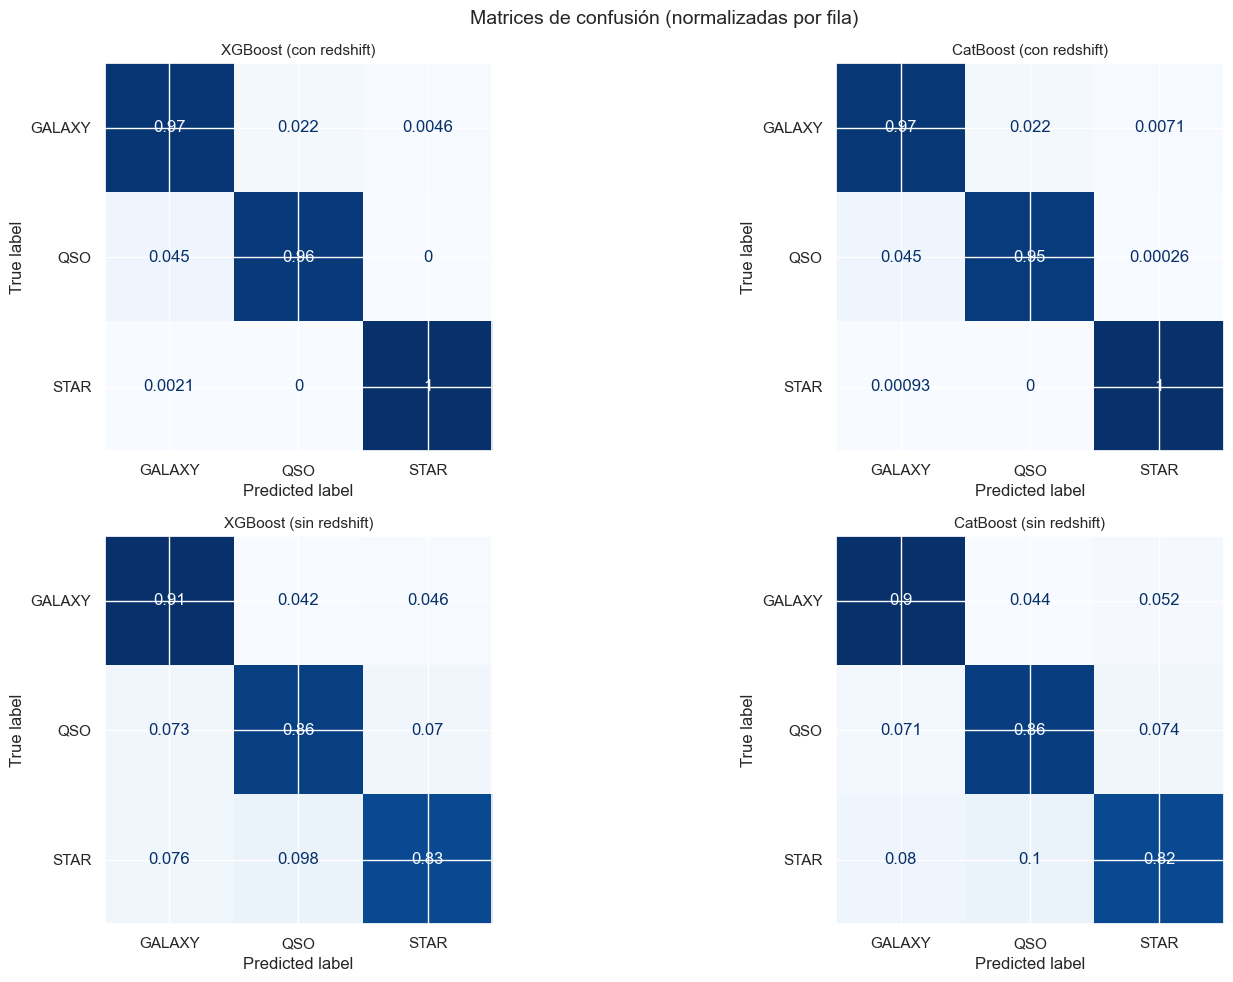

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (nombre, info) in zip(axes.flat, modelos_finales.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, info["y_pred"], display_labels=class_names,
        normalize="true", cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(nombre, fontsize=11)
fig.suptitle("Matrices de confusión (normalizadas por fila)", fontsize=14)
plt.tight_layout(); plt.show()

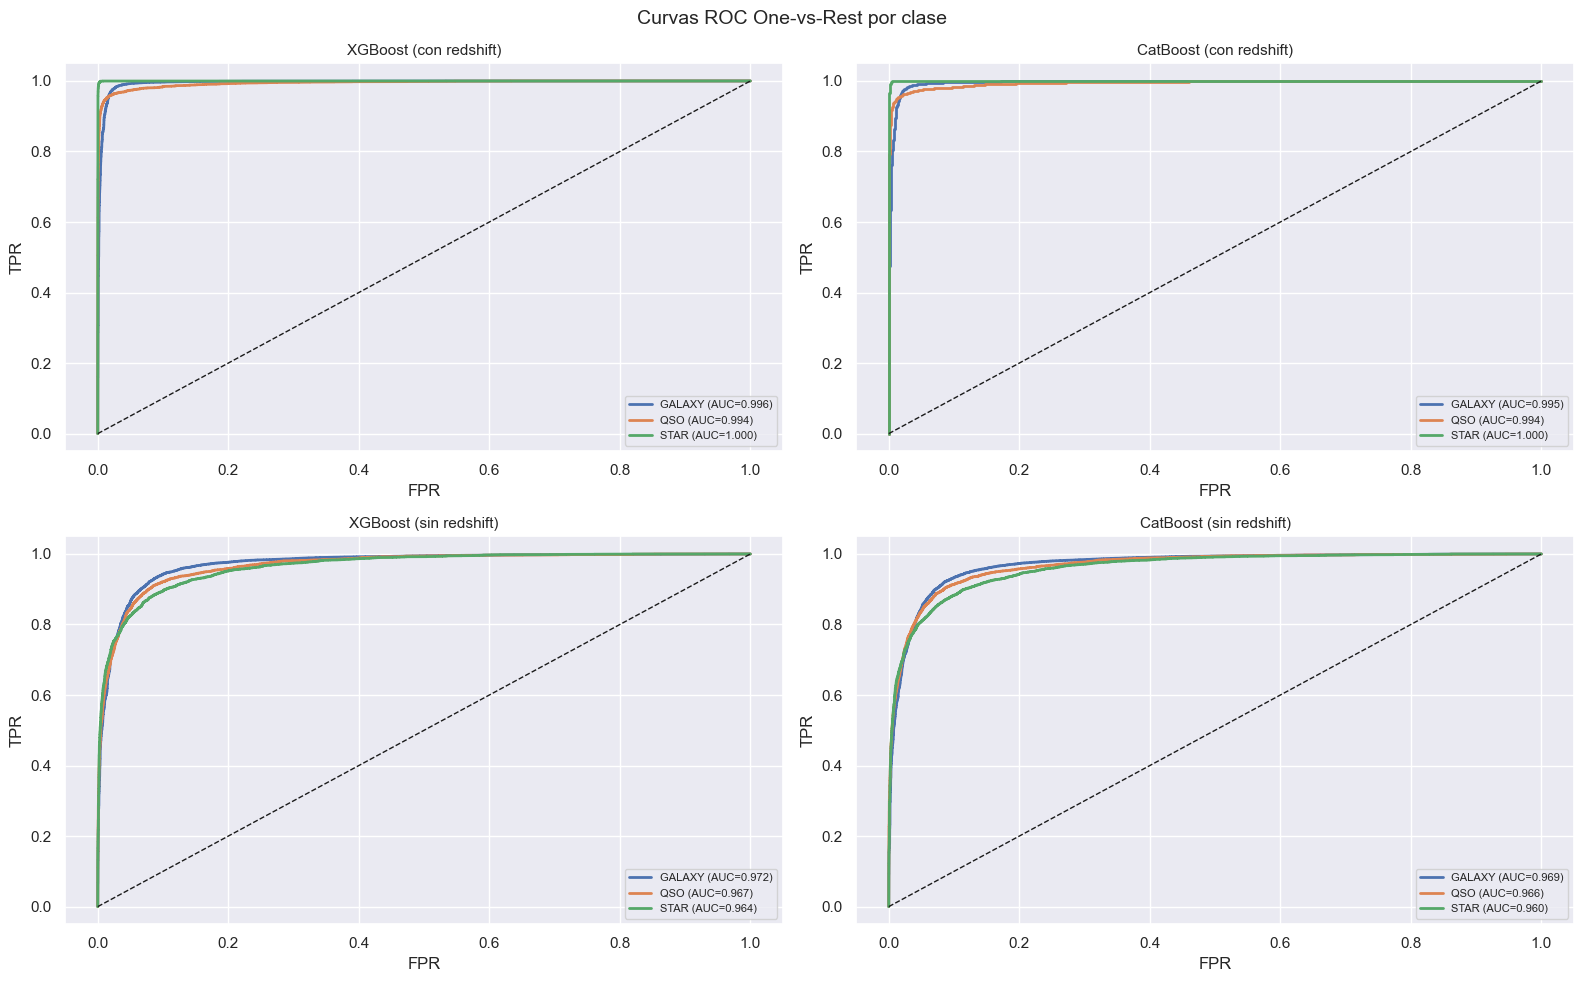

In [42]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=list(range(len(class_names))))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (nombre, info) in zip(axes.flat, modelos_finales.items()):
    proba = info["y_proba"]
    for k, clase in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, k], proba[:, k])
        ax.plot(fpr, tpr, lw=2, label=f"{clase} (AUC={auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("Curvas ROC One-vs-Rest por clase", fontsize=14)
plt.tight_layout(); plt.show()

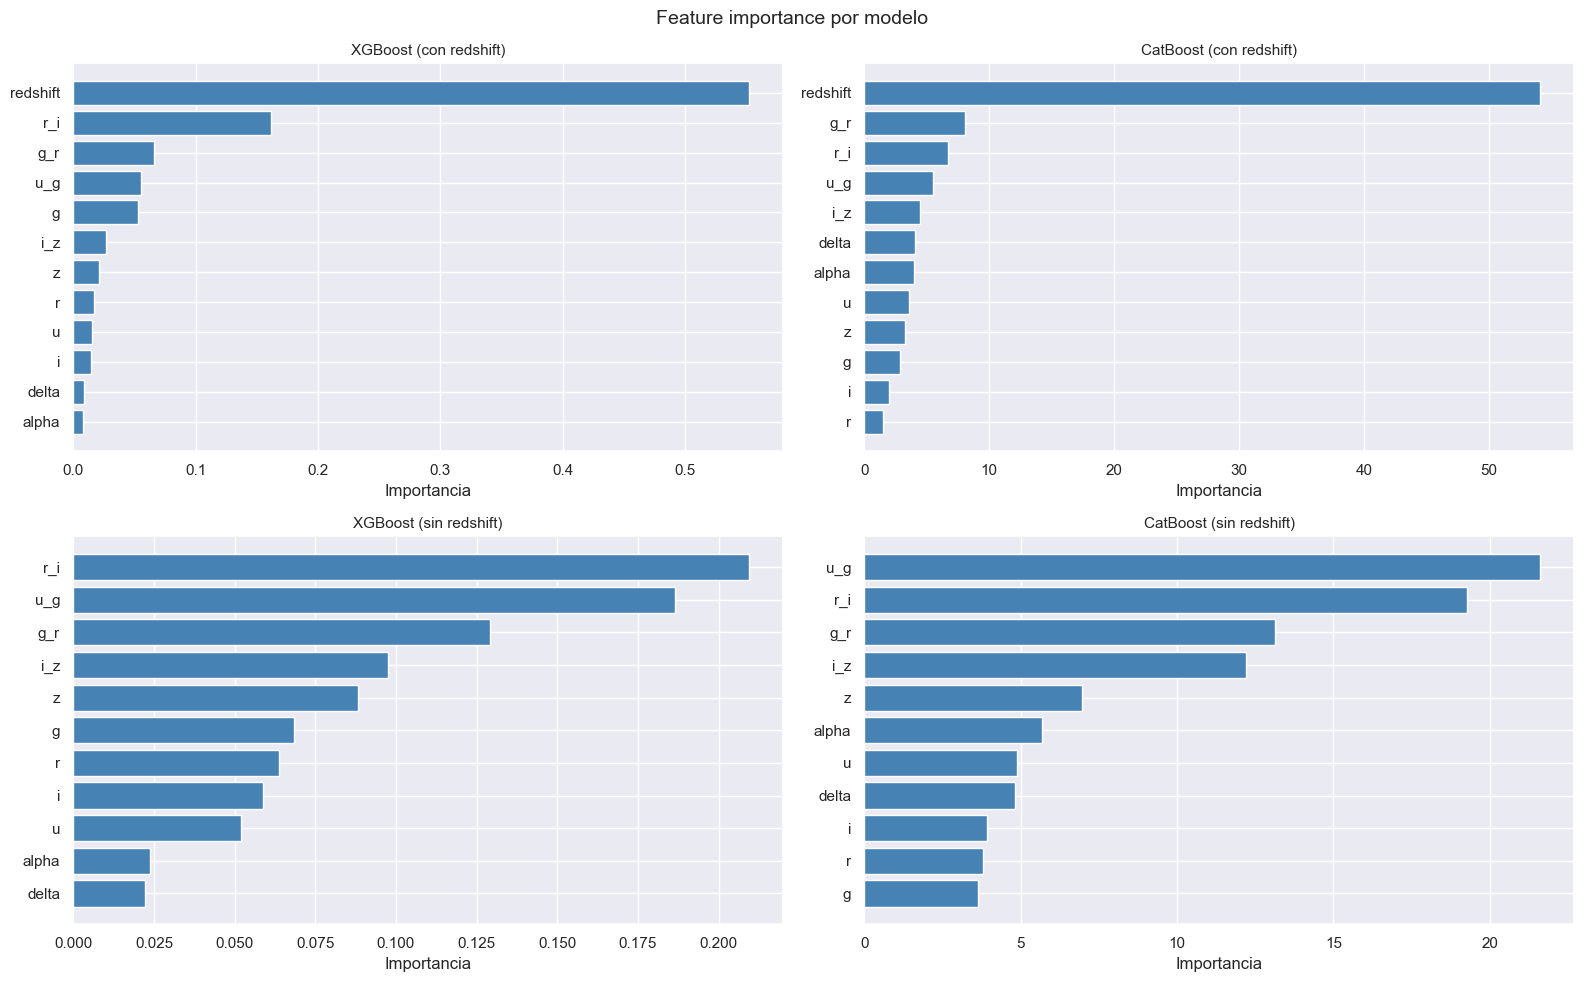

In [43]:
# Feature importance de cada modelo
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (nombre, info) in zip(axes.flat, modelos_finales.items()):
    imp = info["model"].feature_importances_
    orden = np.argsort(imp)
    cols = info["cols"]
    ax.barh(np.array(cols)[orden], imp[orden], color="steelblue")
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Importancia")
fig.suptitle("Feature importance por modelo", fontsize=14)
plt.tight_layout(); plt.show()

# 8. Conclusiones

### La historia de los datos
El análisis exploratorio mostró que el `redshift` separa físicamente las tres clases: las estrellas se concentran cerca de cero, las galaxias ocupan una franja intermedia y los cuásares alcanzan los valores más altos. Las magnitudes fotométricas, en cambio, se solapan bastante entre clases y por sí solas aportan poca información para distinguirlas. Al construir índices de color como diferencias entre bandas, sin embargo, aparece una estructura que el modelo sí puede aprovechar. Sobre esa base definimos un baseline heurístico apoyado en el redshift, que funcionó como vara de medición: cualquier modelo más complejo debía justificar su costo superando ese punto de partida.

### Hallazgos del modelado
El mejor modelo fue XGBoost con redshift, con un F1-macro de 0.976. El baseline por umbral de redshift llegó a 0.939 y el baseline trivial de clase mayoritaria a 0.249. La diferencia respecto del baseline trivial es grande, pero la comparación honesta es contra el baseline de redshift: ahí la mejora es de apenas 3.7 puntos. Esto indica que el redshift por sí solo ya concentra la mayor parte de la información que separa las clases, y que el aporte adicional de la fotometría y los colores, si bien existe, es acotado.

El experimento que retira el `redshift` confirma esa lectura. Al quitarlo, el F1-macro del mejor modelo baja de 0.976 a 0.861, unos 11 puntos. La fotometría con índices de color alcanza por sí sola un desempeño razonable, pero es el redshift la variable que sostiene la separación entre clases. El resultado es coherente con el solapamiento de las magnitudes que ya habíamos observado en el EDA.

Entre las dos implementaciones, XGBoost rindió apenas por encima de CatBoost (0.976 contra 0.973). La diferencia es chica y puede atribuirse a su regularización explícita y a su estabilidad frente a los hiperparámetros que exploramos con Optuna.

La matriz de confusión muestra que los errores se concentran entre galaxias y cuásares. El QSO es la clase con menor recall (alrededor de 0.81), mientras que las estrellas se clasifican casi sin error. Es un comportamiento esperable: los cuásares de bajo redshift solapan el rango y la fotometría de las galaxias, mientras que las estrellas, con redshift cercano a cero, quedan netamente separadas.

### Qué elegimos y qué descartamos
Elegimos XGBoost con redshift porque obtuvo el mejor F1-macro y un buen equilibrio entre las tres clases. Descartamos las variantes sin redshift, que dependen solo de la fotometría, porque pierden alrededor de 11 puntos de F1-macro, en línea con lo que el EDA ya anticipaba sobre el solapamiento de las magnitudes. Conviene remarcar que el baseline por umbral de redshift, mucho más simple, queda a pocos puntos del mejor modelo. La complejidad solo se justifica cuando mejora de forma medible lo que ya ofrecen las reglas sencillas, y en este caso esa mejora existe pero es chica.

# 9. Apéndice de Modelos Extra



Como parte de este trabajo se evaluaron otros modelos como forma de aprendizaje y comparación entre ellos.

Modelos Extras: 

- Regresión Logística
- K-Nearest Neighbors
- Support Vector Machine

In [44]:
X_all = df_model[FEATURES["with_z"]].copy()       # superset; cada modelo elige sus columnas
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_all, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"\nTrain: {X_train_full.shape[0]} filas | Test: {X_test_full.shape[0]} filas")
print(f"Proporción de clases (train): {np.round(np.bincount(y_train) / len(y_train), 3)}")
print(f"Proporción de clases (test): {np.round(np.bincount(y_test) / len(y_test), 3)}")

# --- 6) RandomUnderSampler para balancear el set de entrenamiento
undersample = RandomUnderSampler(random_state=SEED)
X_train_full, y_train = undersample.fit_resample(X_train_full, y_train)


Train: 79999 filas | Test: 20000 filas
Proporción de clases (train): [0.594 0.19  0.216]
Proporción de clases (test): [0.594 0.19  0.216]


### Normalizacion de datos 
Los features tienen rangos muy diferentes y puede causar problemas en en los siguientes modelos. Por lo que se normalizan los datos



In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train_full)
x_test_scaled = scaler.transform(X_test_full)

X_train_no_rs = X_train_full.drop(columns='redshift')
X_test_no_rs = X_test_full.drop(columns='redshift')
x_train_no_rs = scaler.fit_transform(X_train_no_rs)
x_test_no_rs = scaler.fit_transform(X_test_no_rs)

### Regresión Logística

In [46]:
from sklearn.linear_model import LogisticRegression

def rl_train(name, x_train, y_train, x_test, y_test):
  logisticRegression = LogisticRegression(
  max_iter=1000,
  multi_class='multinomial',
  random_state=SEED,
  solver='lbfgs'
  )
  logisticRegression.fit(x_train, y_train)
  y_pred = logisticRegression.predict(x_test)
  registrar(name, y_test, y_pred)

rl_train("RL - redshift", x_train_scaled, y_train, x_test_scaled, y_test)
rl_train("RL - sin redshift", x_train_no_rs, y_train, x_test_no_rs, y_test)


RL - redshift                    | F1-macro=0.9318 | acc=0.9379
RL - sin redshift                | F1-macro=0.5994 | acc=0.6184


### KNN


k= 1 | Train: 1.0000 | Test: 0.9180
k= 2 | Train: 0.9606 | Test: 0.9284
k= 3 | Train: 0.9595 | Test: 0.9300
k= 4 | Train: 0.9504 | Test: 0.9321
k= 5 | Train: 0.9501 | Test: 0.9308
k= 6 | Train: 0.9445 | Test: 0.9312
k= 7 | Train: 0.9438 | Test: 0.9298
k= 8 | Train: 0.9403 | Test: 0.9286
k= 9 | Train: 0.9400 | Test: 0.9270
k=10 | Train: 0.9371 | Test: 0.9266
k=11 | Train: 0.9374 | Test: 0.9257
k=12 | Train: 0.9351 | Test: 0.9260
k=13 | Train: 0.9346 | Test: 0.9245
k=14 | Train: 0.9326 | Test: 0.9244
k=15 | Train: 0.9323 | Test: 0.9228
k=16 | Train: 0.9306 | Test: 0.9238
k=17 | Train: 0.9307 | Test: 0.9217
k=18 | Train: 0.9291 | Test: 0.9212
k=19 | Train: 0.9291 | Test: 0.9203
k=20 | Train: 0.9276 | Test: 0.9201
k=21 | Train: 0.9274 | Test: 0.9188
k=22 | Train: 0.9255 | Test: 0.9188
k=23 | Train: 0.9251 | Test: 0.9182
k=24 | Train: 0.9236 | Test: 0.9184
k=25 | Train: 0.9238 | Test: 0.9173
k=26 | Train: 0.9226 | Test: 0.9173
k=27 | Train: 0.9219 | Test: 0.9165
k=28 | Train: 0.9212 | Test:

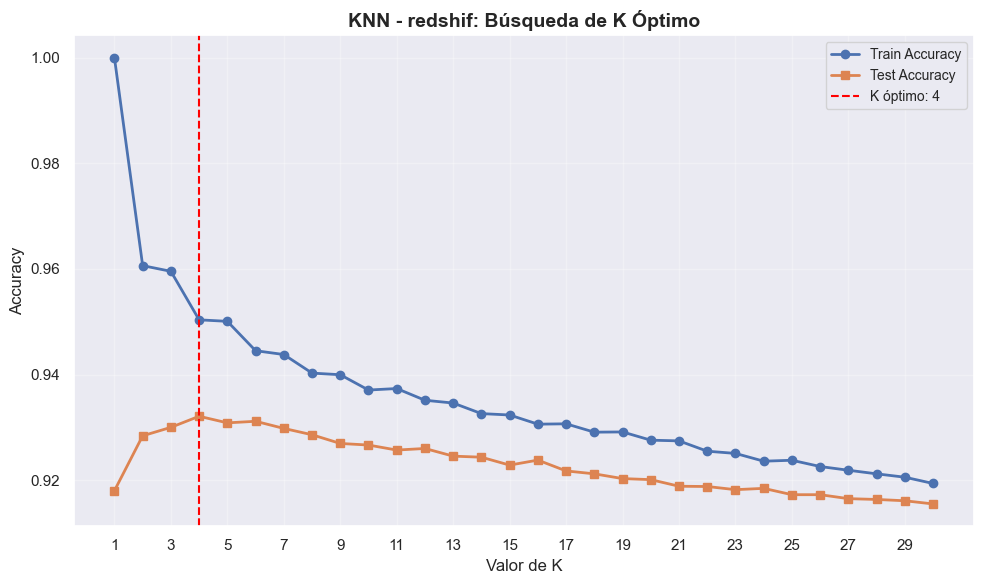

KNN - redshif                    | F1-macro=0.9249 | acc=0.9321
k= 1 | Train: 1.0000 | Test: 0.7343
k= 2 | Train: 0.9022 | Test: 0.7997
k= 3 | Train: 0.8958 | Test: 0.7813
k= 4 | Train: 0.8798 | Test: 0.8043
k= 5 | Train: 0.8757 | Test: 0.7903
k= 6 | Train: 0.8689 | Test: 0.8050
k= 7 | Train: 0.8674 | Test: 0.7948
k= 8 | Train: 0.8630 | Test: 0.8037
k= 9 | Train: 0.8625 | Test: 0.7991
k=10 | Train: 0.8596 | Test: 0.8051
k=11 | Train: 0.8582 | Test: 0.8004
k=12 | Train: 0.8555 | Test: 0.8053
k=13 | Train: 0.8541 | Test: 0.8015
k=14 | Train: 0.8526 | Test: 0.8061
k=15 | Train: 0.8517 | Test: 0.8004
k=16 | Train: 0.8503 | Test: 0.8047
k=17 | Train: 0.8492 | Test: 0.8017
k=18 | Train: 0.8486 | Test: 0.8044
k=19 | Train: 0.8474 | Test: 0.8014
k=20 | Train: 0.8464 | Test: 0.8047
k=21 | Train: 0.8454 | Test: 0.8020
k=22 | Train: 0.8433 | Test: 0.8036
k=23 | Train: 0.8433 | Test: 0.8018
k=24 | Train: 0.8419 | Test: 0.8032
k=25 | Train: 0.8419 | Test: 0.8025
k=26 | Train: 0.8408 | Test: 0.8034


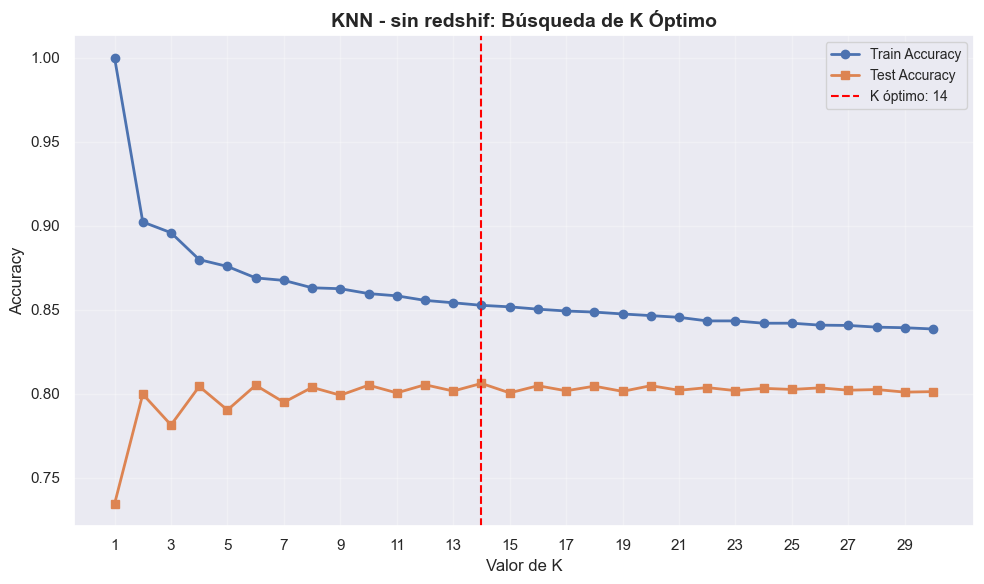

KNN - sin redshif                | F1-macro=0.7763 | acc=0.8061


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

def plotKNN(name, k_values, train_scores, test_scores, k_optimal): 
  plt.figure(figsize=(10, 6))
  plt.plot(k_values, train_scores, marker='o', label='Train Accuracy', linewidth=2)
  plt.plot(k_values, test_scores, marker='s', label='Test Accuracy', linewidth=2)
  plt.axvline(x=k_optimal, color='red', linestyle='--', label=f'K óptimo: {k_optimal}')
  plt.xlabel('Valor de K', fontsize=12)
  plt.ylabel('Accuracy', fontsize=12)
  plt.title(f'{name}: Búsqueda de K Óptimo', fontsize=14, fontweight='bold')
  plt.legend(fontsize=10)
  plt.grid(True, alpha=0.3)
  plt.xticks(range(1, 31, 2))
  plt.tight_layout()
  plt.show()

def trainKNN(name, x_train, y_train, x_test, y_test): 
  k_values = range(1, 31)
  train_scores = []
  test_scores = []
  
  for k in k_values:
      knn = KNeighborsClassifier(n_neighbors=k)
      knn.fit(x_train, y_train)
      
      train_score = knn.score(x_train, y_train)
      test_score = knn.score(x_test, y_test)
      
      train_scores.append(train_score)
      test_scores.append(test_score)
      
      print(f"k={k:2d} | Train: {train_score:.4f} | Test: {test_score:.4f}")
  
  # Encontrar k óptimo
  k_optimal = list(k_values)[np.argmax(test_scores)]
  print(f"\n✓ K ÓPTIMO: {k_optimal} (Accuracy en Test: {max(test_scores):.4f})")

  knn = KNeighborsClassifier(n_neighbors=k_optimal)
  knn.fit(x_train, y_train)
  
  # Predicciones
  y_pred_knn = knn.predict(x_test)
  plotKNN(name, k_values, train_scores, test_scores, k_optimal)
  registrar(name, y_test, y_pred_knn)

trainKNN("KNN - redshif", x_train_scaled, y_train, x_test_scaled, y_test)
trainKNN("KNN - sin redshif", x_train_no_rs, y_train, x_test_no_rs, y_test)

### Support Vector Machine (SVM)

In [48]:
from sklearn.svm import SVC

def svmTrain(name, x_train, y_train, x_test, y_test):
  svm_rbf = SVC(
      kernel='rbf', C=1.0, gamma='scale', random_state=42,
      class_weight='balanced', verbose=0
  )
  svm_rbf.fit(x_train, y_train)
  y_pred_svm = svm_rbf.predict(x_test)
  registrar(name, y_test, y_pred_svm)

svmTrain("SVM - redshif", x_train_scaled, y_train, x_test_scaled, y_test)
svmTrain("SVM - sin redshif", x_train_no_rs, y_train, x_test_no_rs, y_test)

SVM - redshif                    | F1-macro=0.9520 | acc=0.9569
SVM - sin redshif                | F1-macro=0.7902 | acc=0.8200


#### Ajuste de Hiperparámetros con Grid Search

In [49]:
from sklearn.model_selection import GridSearchCV

def svmGridSearchTrain(name, x_train, y_train, x_test, y_test):
  param_grid = {
      'C': [0.1, 1, 10, 100],
      'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
  }

  svm_base = SVC(kernel='rbf', random_state=42, class_weight='balanced')

  grid_search = GridSearchCV(
      svm_base, param_grid, cv=5, scoring='accuracy',
      n_jobs=-1, verbose=1
  )

  grid_search.fit(x_train, y_train)
  print(f"\nMejores parámetros: {grid_search.best_params_}")
  print(f"Mejor CV score (5-fold): {grid_search.best_score_:.4f}")

  results_df = pd.DataFrame(grid_search.cv_results_)
  results_df = results_df[['param_C', 'param_gamma', 'mean_test_score', 'std_test_score']].copy()
  results_df = results_df.sort_values('mean_test_score', ascending=False)

  svm_best = grid_search.best_estimator_

  y_pred_svm_best_train = svm_best.predict(x_test)

  registrar(name, y_test, y_pred_svm_best_train)

svmGridSearchTrain("SVM Grid Search - redshif", x_train_scaled, y_train, x_test_scaled, y_test)
svmGridSearchTrain("SVM Grid Search - sin redshif", x_train_no_rs, y_train, x_test_no_rs, y_test)


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros: {'C': 100, 'gamma': 'scale'}
Mejor CV score (5-fold): 0.9668
SVM Grid Search - redshif        | F1-macro=0.9624 | acc=0.9668
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros: {'C': 100, 'gamma': 'auto'}
Mejor CV score (5-fold): 0.8543
SVM Grid Search - sin redshif    | F1-macro=0.7999 | acc=0.8294


## Comparación con los modelos del apéndice agregados

In [50]:
# Tabla comparativa consolidada, ordenada por F1-macro
tabla = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False).reset_index(drop=True)
cols_fmt = ["f1_macro", "accuracy", "f1_weighted", "roc_auc_ovr"]
tabla.style.format({c: "{:.4f}" for c in cols_fmt}, na_rep="—").background_gradient(subset=["f1_macro"], cmap="Greens")

,modelo,f1_macro,accuracy,f1_weighted,roc_auc_ovr
0,XGBoost (con redshift),0.9718,0.9752,0.9753,0.9965
1,CatBoost (con redshift),0.9706,0.9741,0.9741,0.9964
2,SVM Grid Search - redshif,0.9624,0.9668,0.9668,—
3,SVM - redshif,0.9520,0.9569,0.9570,—
4,Baseline: umbral de redshift,0.9393,0.9497,0.9484,—
5,RL - redshift,0.9318,0.9379,0.9381,—
6,KNN - redshif,0.9249,0.9321,0.9323,—
7,XGBoost (sin redshift),0.8553,0.8831,0.8843,0.9678
8,CatBoost (sin redshift),0.8482,0.8766,0.8781,0.9649
9,SVM Grid Search - sin redshif,0.7999,0.8294,0.8336,—


# 10. Referencias y bibliografía

**Fuente de datos**
- fedesoriano (2022). *Stellar Classification Dataset SDSS17*. Kaggle. https://www.kaggle.com/fedesoriano/stellar-classification-dataset-sdss17
- Sloan Digital Sky Survey, Data Release 17. https://www.sdss.org/dr17/

**Material de divulgación**
- SDSS Voyages. *Light: Filters*. https://voyages.sdss.org/preflight/light/filters/
- SDSS Voyages. *Light: Redshift*. https://voyages.sdss.org/preflight/light/redshift/

**Bibliografía de referencia**
- James, G., Witten, D., Hastie, T., Tibshirani, R. *An Introduction to Statistical Learning*. Springer. https://www.statlearning.com/
- Hastie, T., Tibshirani, R., Friedman, J. *The Elements of Statistical Learning*. Springer.
- Bruce, P. *Practical Statistics for Data Scientists*. O'Reilly.

**Herramientas**
- Chen, T., Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. https://arxiv.org/abs/1603.02754
- Prokhorenkova et al. (2017). *CatBoost: unbiased boosting with categorical features*. https://arxiv.org/abs/1706.09516
- Akiba et al. (2019). *Optuna: A Next-generation Hyperparameter Optimization Framework*. https://arxiv.org/abs/1907.10902